# MyTadika — AI Health Advice: Data Preparation
## Tasks: Data Audit, Cleaning & Exploratory Analysis

**Final Year Project — Health & Nutrition Module**

This notebook covers the full data preparation pipeline:
- **Task 1**: Data Collection & Audit
- **Task 2**: Data Cleaning & Preprocessing
- **Task 3**: Exploratory Data Analysis (EDA)

The output is a clean, analysis-ready dataset for model training in Task 4+.

---
## 0. Setup & Imports

In [1]:
# ── Core Libraries ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
import warnings
import os

# ── Configuration ────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Plot Style ───────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# ── Paths ─────────────────────────────────────────────────────────────
MALNUTRITION_PATH = os.path.join('dataset', 'Children Malnutrition Dataset', 'malnutrition_data (1).csv')
ALLERGY_PATH = os.path.join('dataset', 'Childhood Allergies Prevalence, Demographics', 'food-allergy-analysis-Zenodo.csv')
CLEAN_OUTPUT_PATH = os.path.join('dataset', 'cleaned_malnutrition_data.csv')
CLEAN_ALLERGY_OUTPUT_PATH = os.path.join('dataset', 'cleaned_allergy_data.csv')

print('Setup complete.')
print(f'Malnutrition data: {MALNUTRITION_PATH}')
print(f'Allergy data:      {ALLERGY_PATH}')

Setup complete.
Malnutrition data: dataset\Children Malnutrition Dataset\malnutrition_data (1).csv
Allergy data:      dataset\Childhood Allergies Prevalence, Demographics\food-allergy-analysis-Zenodo.csv


---
# TASK 1 — Data Collection & Audit
---

## 1.1 Load the Malnutrition Dataset

In [2]:
# Load the malnutrition dataset
df_raw = pd.read_csv(MALNUTRITION_PATH)

print(f'Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')
print(f'\nColumns: {list(df_raw.columns)}')
print(f'\nData types:')
print(df_raw.dtypes)
print(f'\nFirst 10 rows:')
df_raw.head(10)

Shape: 5000 rows × 6 columns

Columns: ['age_months', 'weight_kg', 'height_cm', 'muac_cm', 'bmi', 'nutrition_status']

Data types:
age_months          float64
weight_kg           float64
height_cm           float64
muac_cm             float64
bmi                 float64
nutrition_status     object
dtype: object

First 10 rows:


,age_months,weight_kg,height_cm,muac_cm,bmi,nutrition_status
0,12.3451,3.0000,54.1340,13.1609,10.0000,normal
1,30.8072,5.4591,76.1992,13.9444,10.0000,normal
2,15.7232,3.0000,60.2808,13.2436,10.0000,normal
3,57.7963,10.1031,104.9905,14.1057,10.0000,normal
4,40.3213,7.1106,85.2779,14.6416,10.0000,normal
5,46.1653,7.8749,94.0174,13.8346,10.0000,normal
6,46.9255,5.6988,93.4163,12.3394,10.0000,moderate
7,53.1434,9.2036,99.6579,13.2719,10.0000,normal
8,31.8124,5.5470,77.0082,13.9587,10.0000,normal
9,47.5611,8.3464,96.5257,13.9928,10.0000,normal


## 1.2 Schema Validation

In [3]:
# ── Define expected schema ────────────────────────────────────────────
EXPECTED_SCHEMA = {
    'age_months':        'numeric',
    'weight_kg':         'numeric',
    'height_cm':         'numeric',
    'muac_cm':           'numeric',
    'bmi':               'numeric',
    'nutrition_status':  'categorical'
}

print('=== SCHEMA VALIDATION REPORT ===')
print()

# Check all expected columns exist
missing_cols = set(EXPECTED_SCHEMA.keys()) - set(df_raw.columns)
extra_cols = set(df_raw.columns) - set(EXPECTED_SCHEMA.keys())

if missing_cols:
    print(f'❌ MISSING columns: {missing_cols}')
else:
    print('✅ All expected columns present')

if extra_cols:
    print(f'⚠️  Extra columns found: {extra_cols}')
else:
    print('✅ No unexpected columns')

# Check data types
print('\n--- Column Type Checks ---')
for col, expected_type in EXPECTED_SCHEMA.items():
    if col not in df_raw.columns:
        continue
    actual_dtype = df_raw[col].dtype
    if expected_type == 'numeric':
        is_valid = np.issubdtype(actual_dtype, np.number)
    else:  # categorical
        is_valid = actual_dtype == 'object' or pd.api.types.is_categorical_dtype(actual_dtype)
    status = '✅' if is_valid else '❌'
    print(f'  {status} {col}: expected={expected_type}, actual={actual_dtype}')

=== SCHEMA VALIDATION REPORT ===

✅ All expected columns present
✅ No unexpected columns

--- Column Type Checks ---
  ✅ age_months: expected=numeric, actual=float64
  ✅ weight_kg: expected=numeric, actual=float64
  ✅ height_cm: expected=numeric, actual=float64
  ✅ muac_cm: expected=numeric, actual=float64
  ✅ bmi: expected=numeric, actual=float64
  ✅ nutrition_status: expected=categorical, actual=object


## 1.3 Completeness Check (Missing Values)

In [4]:
# ── Missing value analysis ────────────────────────────────────────────
missing_report = pd.DataFrame({
    'Column': df_raw.columns,
    'Missing Count': df_raw.isnull().sum().values,
    'Missing %': (df_raw.isnull().sum().values / len(df_raw) * 100).round(2),
    'Non-Null Count': df_raw.notnull().sum().values,
    'Dtype': df_raw.dtypes.values
})

print('=== COMPLETENESS REPORT ===')
print(f'Total rows: {len(df_raw)}')
print(f'Total columns: {len(df_raw.columns)}')
print(f'Total missing values: {df_raw.isnull().sum().sum()}')
print(f'Rows with any missing: {df_raw.isnull().any(axis=1).sum()}')
print()
print(missing_report.to_string(index=False))

# Check for empty strings or whitespace-only values in string columns
for col in df_raw.select_dtypes(include='object').columns:
    empty_strings = (df_raw[col].str.strip() == '').sum()
    if empty_strings > 0:
        print(f'\n⚠️  {col}: {empty_strings} empty/whitespace-only strings found')

=== COMPLETENESS REPORT ===
Total rows: 5000
Total columns: 6
Total missing values: 0
Rows with any missing: 0

          Column  Missing Count  Missing %  Non-Null Count   Dtype
      age_months              0     0.0000            5000 float64
       weight_kg              0     0.0000            5000 float64
       height_cm              0     0.0000            5000 float64
         muac_cm              0     0.0000            5000 float64
             bmi              0     0.0000            5000 float64
nutrition_status              0     0.0000            5000  object


## 1.4 Range Validation (Physiological Bounds)

In [5]:
# ── Physiological bounds for children aged 0–6 years ────────────────
# These are generous bounds — values outside are almost certainly errors.
VALID_RANGES = {
    'age_months':  (0, 72),       # 0 to 6 years
    'weight_kg':   (2.0, 35.0),   # WHO extremes for 0–6 year-olds
    'height_cm':   (40.0, 135.0), # WHO extremes for 0–6 year-olds
    'muac_cm':     (8.0, 25.0),   # WHO/UNICEF MUAC ranges
    'bmi':         (8.0, 28.0)    # Paediatric BMI range
}

print('=== RANGE VALIDATION REPORT ===')
print(f'{"Column":<15} {"Min":>10} {"Max":>10} {"Valid Range":>15} {"Below":>8} {"Above":>8} {"% Out":>8}')
print('-' * 80)

range_issues = {}
for col, (lo, hi) in VALID_RANGES.items():
    col_data = df_raw[col].dropna()
    below = (col_data < lo).sum()
    above = (col_data > hi).sum()
    pct_out = ((below + above) / len(col_data) * 100)
    range_issues[col] = {'below': below, 'above': above, 'pct_out': pct_out}
    flag = '⚠️ ' if (below + above) > 0 else '✅'
    print(f'{flag} {col:<13} {col_data.min():>10.2f} {col_data.max():>10.2f} {f"[{lo}, {hi}]":>15} {below:>8} {above:>8} {pct_out:>7.2f}%')

# Show actual out-of-range rows if any
total_oor = sum(v['below'] + v['above'] for v in range_issues.values())
print(f'\nTotal out-of-range values: {total_oor}')

if total_oor > 0:
    print('\n--- Sample out-of-range rows ---')
    mask = pd.Series(False, index=df_raw.index)
    for col, (lo, hi) in VALID_RANGES.items():
        mask = mask | (df_raw[col] < lo) | (df_raw[col] > hi)
    print(df_raw[mask].head(20))

=== RANGE VALIDATION REPORT ===
Column                 Min        Max     Valid Range    Below    Above    % Out
--------------------------------------------------------------------------------
✅ age_months          1.00      59.99         [0, 72]        0        0    0.00%
✅ weight_kg           3.00      10.73     [2.0, 35.0]        0        0    0.00%
✅ height_cm          45.00     105.00   [40.0, 135.0]        0        0    0.00%
✅ muac_cm            10.26      15.72     [8.0, 25.0]        0        0    0.00%
✅ bmi                10.00      11.29     [8.0, 28.0]        0        0    0.00%

Total out-of-range values: 0


## 1.5 Duplicate Detection

In [6]:
# ── Exact duplicates ──────────────────────────────────────────────────
exact_dups = df_raw.duplicated().sum()
print(f'=== DUPLICATE DETECTION ===')
print(f'Exact duplicate rows: {exact_dups} ({exact_dups/len(df_raw)*100:.2f}%)')

if exact_dups > 0:
    print('\nSample duplicates:')
    print(df_raw[df_raw.duplicated(keep=False)].sort_values(by=list(df_raw.columns)).head(10))

# ── Near-duplicates (same numeric values, potentially different precision)
numeric_cols = ['age_months', 'weight_kg', 'height_cm', 'muac_cm', 'bmi']
df_rounded = df_raw[numeric_cols].round(1)
near_dups = df_rounded.duplicated().sum()
print(f'\nNear-duplicates (numerics rounded to 1 decimal): {near_dups} ({near_dups/len(df_raw)*100:.2f}%)')

=== DUPLICATE DETECTION ===
Exact duplicate rows: 0 (0.00%)

Near-duplicates (numerics rounded to 1 decimal): 13 (0.26%)


## 1.6 Label Audit & Class Distribution

In [7]:
# ── Label audit ───────────────────────────────────────────────────────
print('=== LABEL AUDIT ===')
print(f'Target column: nutrition_status')
print(f'Unique values: {df_raw["nutrition_status"].unique()}')
print(f'Number of classes: {df_raw["nutrition_status"].nunique()}')
print()

# Class distribution
class_dist = df_raw['nutrition_status'].value_counts()
class_pct = df_raw['nutrition_status'].value_counts(normalize=True) * 100

dist_report = pd.DataFrame({
    'Class': class_dist.index,
    'Count': class_dist.values,
    'Percentage': class_pct.values.round(2)
})
print(dist_report.to_string(index=False))

# Imbalance ratio
majority = class_dist.max()
minority = class_dist.min()
print(f'\nImbalance ratio (majority:minority): {majority/minority:.1f}:1')

if majority / minority > 3:
    print('⚠️  Significant class imbalance detected — will need SMOTE or class weights in training')

=== LABEL AUDIT ===
Target column: nutrition_status
Unique values: ['normal' 'moderate' 'severe']
Number of classes: 3

   Class  Count  Percentage
  normal   3550     71.0000
moderate   1100     22.0000
  severe    350      7.0000

Imbalance ratio (majority:minority): 10.1:1
⚠️  Significant class imbalance detected — will need SMOTE or class weights in training


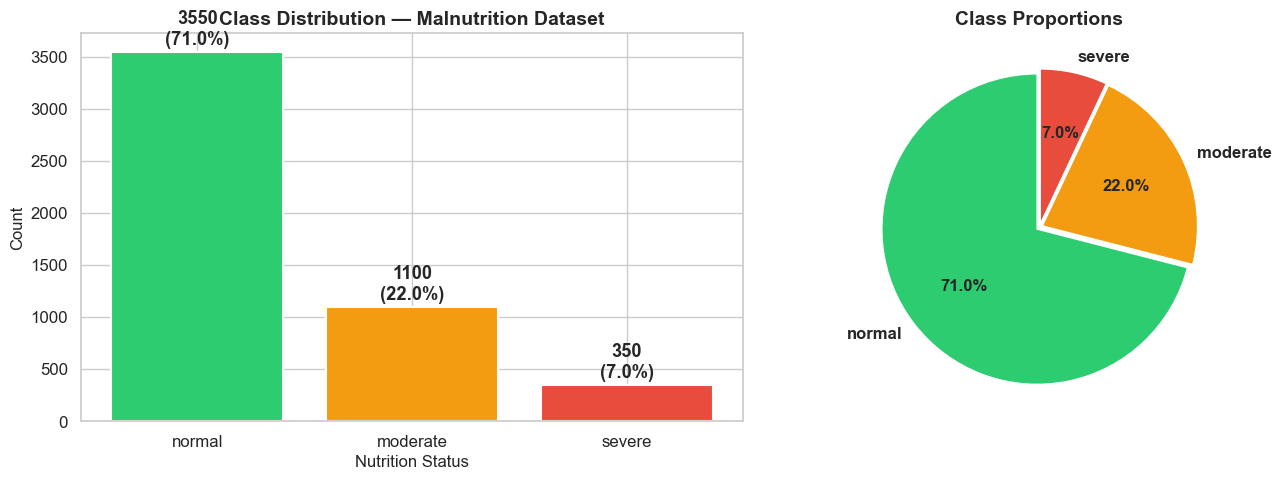

Saved: dataset/class_distribution.png


In [8]:
# ── Visualise class distribution ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = {'normal': '#2ecc71', 'moderate': '#f39c12', 'severe': '#e74c3c'}
bars = axes[0].bar(
    class_dist.index, class_dist.values,
    color=[colors.get(c, '#95a5a6') for c in class_dist.index],
    edgecolor='white', linewidth=1.5
)
for bar, count, pct in zip(bars, class_dist.values, class_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Class Distribution — Malnutrition Dataset', fontweight='bold')
axes[0].set_xlabel('Nutrition Status')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(
    class_dist.values, labels=class_dist.index,
    colors=[colors.get(c, '#95a5a6') for c in class_dist.index],
    autopct='%1.1f%%', startangle=90, explode=[0.02]*len(class_dist),
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)
axes[1].set_title('Class Proportions', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join('dataset', 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dataset/class_distribution.png')

## 1.7 Summary Statistics

In [9]:
# ── Comprehensive summary statistics ─────────────────────────────────
numeric_cols = ['age_months', 'weight_kg', 'height_cm', 'muac_cm', 'bmi']

summary = df_raw[numeric_cols].describe().T
summary['skewness'] = df_raw[numeric_cols].skew()
summary['kurtosis'] = df_raw[numeric_cols].kurtosis()
summary['iqr'] = summary['75%'] - summary['25%']
summary['cv'] = (summary['std'] / summary['mean'] * 100).round(2)  # coefficient of variation

print('=== SUMMARY STATISTICS (ALL DATA) ===')
print(summary.round(4))

=== SUMMARY STATISTICS (ALL DATA) ===
               count    mean     std     min     25%     50%     75%      max  \
age_months 5000.0000 30.3295 17.1524  1.0007 15.2969 30.6079 45.1440  59.9896   
weight_kg  5000.0000  5.2853  2.3409  3.0000  3.0000  4.6490  7.0434  10.7269   
height_cm  5000.0000 75.1503 17.3326 45.0000 60.1808 75.0100 89.3666 105.0000   
muac_cm    5000.0000 13.4415  0.8856 10.2620 12.8494 13.6356 14.0826  15.7151   
bmi        5000.0000 10.0043  0.0473 10.0000 10.0000 10.0000 10.0000  11.2854   

            skewness  kurtosis     iqr      cv  
age_months   -0.0020   -1.2146 29.8470 56.5500  
weight_kg     0.6541   -0.8702  4.0434 44.2900  
height_cm     0.0440   -1.1600 29.1859 23.0600  
muac_cm      -0.6181   -0.2347  1.2331  6.5900  
bmi          16.1106  319.4913  0.0000  0.4700  


In [10]:
# ── Summary statistics grouped by nutrition_status ──────────────────
print('=== SUMMARY STATISTICS BY NUTRITION STATUS ===')
for status in df_raw['nutrition_status'].unique():
    subset = df_raw[df_raw['nutrition_status'] == status][numeric_cols]
    desc = subset.describe().T
    desc['skewness'] = subset.skew()
    desc['kurtosis'] = subset.kurtosis()
    print(f'\n--- {status.upper()} (n={len(subset)}) ---')
    print(desc[['mean', 'std', 'min', '25%', '50%', '75%', 'max', 'skewness']].round(3))

=== SUMMARY STATISTICS BY NUTRITION STATUS ===

--- NORMAL (n=3550) ---
              mean     std     min     25%     50%     75%      max  skewness
age_months 30.4370 17.1610  1.0010 15.4850 30.8160 45.2480  59.9830   -0.0130
weight_kg   5.7300  2.4970  3.0000  3.0000  5.3780  7.9050  10.7270    0.3620
height_cm  76.8510 17.9100 45.0000 61.3620 77.2620 92.5150 105.0000   -0.0450
muac_cm    13.8990  0.4970 12.2220 13.5630 13.8940 14.2310  15.7150    0.0160
bmi        10.0060  0.0560 10.0000 10.0000 10.0000 10.0000  11.2850   13.5520

--- MODERATE (n=1100) ---
              mean     std     min     25%     50%     75%      max  skewness
age_months 29.9860 17.1500  1.0110 14.8180 30.3310 44.7960  59.8910    0.0250
weight_kg   4.3400  1.4830  3.0000  3.0000  3.7890  5.5840   7.6980    0.6720
height_cm  72.0640 15.5090 45.0000 58.1090 72.0740 85.2620 103.5870    0.0360
muac_cm    12.4880  0.5000 10.5610 12.1490 12.4810 12.8310  13.9060   -0.0430
bmi        10.0000  0.0000 10.0000 10.0000 

## 1.8 Allergy Dataset Audit

In [11]:
# ── Load and audit the allergy dataset ────────────────────────────────
print('Loading allergy dataset (this may take a moment due to ~88MB file)...')
df_allergy_raw = pd.read_csv(ALLERGY_PATH, low_memory=False)

print(f'\n=== ALLERGY DATASET AUDIT ===')
print(f'Shape: {df_allergy_raw.shape[0]} rows × {df_allergy_raw.shape[1]} columns')
print(f'\nColumns ({len(df_allergy_raw.columns)}):')
for i, col in enumerate(df_allergy_raw.columns):
    non_null = df_allergy_raw[col].notna().sum()
    pct = non_null / len(df_allergy_raw) * 100
    print(f'  {i+1:>2}. {col:<30} non-null: {non_null:>8} ({pct:>6.2f}%)')

Loading allergy dataset (this may take a moment due to ~88MB file)...



=== ALLERGY DATASET AUDIT ===
Shape: 333200 rows × 50 columns

Columns (50):
   1. SUBJECT_ID                     non-null:   333200 (100.00%)
   2. BIRTH_YEAR                     non-null:   333200 (100.00%)
   3. GENDER_FACTOR                  non-null:   333200 (100.00%)
   4. RACE_FACTOR                    non-null:   333200 (100.00%)
   5. ETHNICITY_FACTOR               non-null:   333200 (100.00%)
   6. PAYER_FACTOR                   non-null:   333200 (100.00%)
   7. ATOPIC_MARCH_COHORT            non-null:   333200 (100.00%)
   8. AGE_START_YEARS                non-null:   333200 (100.00%)
   9. AGE_END_YEARS                  non-null:   333200 (100.00%)
  10. SHELLFISH_ALG_START            non-null:     5246 (  1.57%)
  11. SHELLFISH_ALG_END              non-null:     1051 (  0.32%)
  12. FISH_ALG_START                 non-null:     1796 (  0.54%)
  13. FISH_ALG_END                   non-null:      527 (  0.16%)
  14. MILK_ALG_START                 non-null:     7289 (  2.19%

In [12]:
# ── Demographics overview ─────────────────────────────────────────────
print('=== ALLERGY DEMOGRAPHICS ===')
print(f'\nGender distribution:')
print(df_allergy_raw['GENDER_FACTOR'].value_counts())
print(f'\nRace distribution:')
print(df_allergy_raw['RACE_FACTOR'].value_counts())
print(f'\nEthnicity distribution:')
print(df_allergy_raw['ETHNICITY_FACTOR'].value_counts())
print(f'\nBirth year range: {df_allergy_raw["BIRTH_YEAR"].min()} – {df_allergy_raw["BIRTH_YEAR"].max()}')
print(f'Age range (start): {df_allergy_raw["AGE_START_YEARS"].min():.2f} – {df_allergy_raw["AGE_START_YEARS"].max():.2f} years')
print(f'Age range (end):   {df_allergy_raw["AGE_END_YEARS"].min():.2f} – {df_allergy_raw["AGE_END_YEARS"].max():.2f} years')

=== ALLERGY DEMOGRAPHICS ===

Gender distribution:
GENDER_FACTOR
S0 - Male      169032
S1 - Female    164168
Name: count, dtype: int64

Race distribution:
RACE_FACTOR
R0 - White                        183308
R1 - Black                         97795
R4 - Unknown                       40940
R2 - Asian or Pacific Islander      9152
R3 - Other                          2005
Name: count, dtype: int64

Ethnicity distribution:
ETHNICITY_FACTOR
E0 - Non-Hispanic    317868
E1 - Hispanic         15332
Name: count, dtype: int64

Birth year range: 1983 – 2012
Age range (start): -4.31 – 17.98 years
Age range (end):   1.00 – 19.00 years


In [13]:
# ── Allergen prevalence analysis ──────────────────────────────────────
# Identify all allergen START columns (presence indicator)
allergen_start_cols = [c for c in df_allergy_raw.columns if c.endswith('_ALG_START')]
allergen_names = [c.replace('_ALG_START', '') for c in allergen_start_cols]

print('=== ALLERGEN PREVALENCE ===')
prevalence = {}
for col, name in zip(allergen_start_cols, allergen_names):
    has_allergy = df_allergy_raw[col].notna().sum()
    pct = has_allergy / len(df_allergy_raw) * 100
    prevalence[name] = {'count': has_allergy, 'pct': pct}
    print(f'  {name:<15} {has_allergy:>8} ({pct:>5.2f}%)')

# Top allergens
prev_df = pd.DataFrame(prevalence).T.sort_values('count', ascending=False)
print(f'\nTop 5 most prevalent allergens:')
for name, row in prev_df.head(5).iterrows():
    print(f'  {name}: {int(row["count"])} cases ({row["pct"]:.2f}%)')

=== ALLERGEN PREVALENCE ===
  SHELLFISH           5246 ( 1.57%)
  FISH                1796 ( 0.54%)
  MILK                7289 ( 2.19%)
  SOY                 2419 ( 0.73%)
  EGG                 6065 ( 1.82%)
  WHEAT               1146 ( 0.34%)
  PEANUT              8653 ( 2.60%)
  SESAME               766 ( 0.23%)
  TREENUT                1 ( 0.00%)
  WALNUT               704 ( 0.21%)
  PECAN                285 ( 0.09%)
  PISTACH              369 ( 0.11%)
  ALMOND               386 ( 0.12%)
  BRAZIL                68 ( 0.02%)
  HAZELNUT             253 ( 0.08%)
  CASHEW               561 ( 0.17%)

Top 5 most prevalent allergens:
  PEANUT: 8653 cases (2.60%)
  MILK: 7289 cases (2.19%)
  EGG: 6065 cases (1.82%)
  SHELLFISH: 5246 cases (1.57%)
  SOY: 2419 cases (0.73%)


In [14]:
# ── Filter for tadika-relevant age group (0–6 years) ─────────────────
df_allergy_children = df_allergy_raw[df_allergy_raw['AGE_START_YEARS'] <= 6].copy()
print(f'=== FILTERED TO AGES 0–6 ===')
print(f'Rows after age filter: {len(df_allergy_children)} / {len(df_allergy_raw)} ({len(df_allergy_children)/len(df_allergy_raw)*100:.1f}%)')
print(f'\nAllergen prevalence (ages 0–6 only):')
for col, name in zip(allergen_start_cols, allergen_names):
    has_allergy = df_allergy_children[col].notna().sum()
    pct = has_allergy / len(df_allergy_children) * 100 if len(df_allergy_children) > 0 else 0
    print(f'  {name:<15} {has_allergy:>8} ({pct:>5.2f}%)')

=== FILTERED TO AGES 0–6 ===


Rows after age filter: 233495 / 333200 (70.1%)

Allergen prevalence (ages 0–6 only):
  SHELLFISH           3414 ( 1.46%)
  FISH                1332 ( 0.57%)
  MILK                6576 ( 2.82%)
  SOY                 2145 ( 0.92%)
  EGG                 5531 ( 2.37%)
  WHEAT                994 ( 0.43%)
  PEANUT              7177 ( 3.07%)
  SESAME               672 ( 0.29%)
  TREENUT                1 ( 0.00%)
  WALNUT               559 ( 0.24%)
  PECAN                227 ( 0.10%)
  PISTACH              310 ( 0.13%)
  ALMOND               304 ( 0.13%)
  BRAZIL                55 ( 0.02%)
  HAZELNUT             209 ( 0.09%)
  CASHEW               494 ( 0.21%)


## 1.9 Task 1 — Audit Summary

In [15]:
print('=' * 60)
print('   TASK 1 — DATA AUDIT SUMMARY')
print('=' * 60)
print(f'''
MALNUTRITION DATASET:
  • Rows: {len(df_raw):,}
  • Columns: {len(df_raw.columns)}
  • Missing values: {df_raw.isnull().sum().sum()}
  • Exact duplicates: {exact_dups}
  • Out-of-range values: {total_oor}
  • Class imbalance: {majority/minority:.1f}:1
  • Classes: normal ({class_dist.get("normal", 0)}), 
             moderate ({class_dist.get("moderate", 0)}), 
             severe ({class_dist.get("severe", 0)})

ALLERGY DATASET:
  • Total rows: {len(df_allergy_raw):,}
  • Filtered to ages 0–6: {len(df_allergy_children):,}
  • Allergen types tracked: {len(allergen_start_cols)}

KEY FINDINGS:
  1. Significant class imbalance (severe = {class_dist.get("severe", 0)/len(df_raw)*100:.1f}%)
     → Must apply SMOTE/class weights during training
  2. BMI values appear to need verification against weight/height
  3. Label mapping needed: dataset uses normal/moderate/severe
     but adviceTemplates.js uses 0(underweight)/1(normal)/2(overweight)
''')

   TASK 1 — DATA AUDIT SUMMARY

MALNUTRITION DATASET:
  • Rows: 5,000
  • Columns: 6
  • Missing values: 0
  • Exact duplicates: 0
  • Out-of-range values: 0
  • Class imbalance: 10.1:1
  • Classes: normal (3550), 
             moderate (1100), 
             severe (350)

ALLERGY DATASET:
  • Total rows: 333,200
  • Filtered to ages 0–6: 233,495
  • Allergen types tracked: 16

KEY FINDINGS:
  1. Significant class imbalance (severe = 7.0%)
     → Must apply SMOTE/class weights during training
  2. BMI values appear to need verification against weight/height
  3. Label mapping needed: dataset uses normal/moderate/severe
     but adviceTemplates.js uses 0(underweight)/1(normal)/2(overweight)



---
# TASK 2 — Data Cleaning & Preprocessing
---

## 2.1 Create Working Copy & BMI Verification

In [16]:
# ── Working copy for cleaning ─────────────────────────────────────────
df = df_raw.copy()
cleaning_log = []  # Track all cleaning decisions

def log_step(step, before_rows, after_rows, details=''):
    """Log a cleaning step for the final report."""
    removed = before_rows - after_rows
    cleaning_log.append({
        'Step': step,
        'Before': before_rows,
        'After': after_rows,
        'Removed': removed,
        'Details': details
    })
    print(f'  [{step}] {before_rows} → {after_rows} rows ({removed} removed). {details}')

print(f'Working copy created: {len(df)} rows')
initial_rows = len(df)

Working copy created: 5000 rows


In [17]:
# ── 2.1a: Verify BMI = weight / (height/100)^2 ────────────────────────
df['bmi_computed'] = df['weight_kg'] / (df['height_cm'] / 100) ** 2
df['bmi_diff'] = abs(df['bmi'] - df['bmi_computed'])

bmi_mismatch_threshold = 0.5  # allow small floating point tolerance
bmi_mismatches = (df['bmi_diff'] > bmi_mismatch_threshold).sum()

print(f'=== BMI VERIFICATION ===')
print(f'BMI mismatches (|recorded - computed| > {bmi_mismatch_threshold}): {bmi_mismatches}')
print(f'Mean absolute difference: {df["bmi_diff"].mean():.4f}')
print(f'Max absolute difference: {df["bmi_diff"].max():.4f}')

if bmi_mismatches > 0:
    print(f'\n⚠️  {bmi_mismatches} rows have BMI mismatches — replacing with computed BMI')
    print('Sample mismatches:')
    print(df[df['bmi_diff'] > bmi_mismatch_threshold][['weight_kg', 'height_cm', 'bmi', 'bmi_computed', 'bmi_diff']].head(10))

# Replace original BMI with verified computed BMI
df['bmi_original'] = df['bmi']
df['bmi'] = df['bmi_computed']
df.drop(columns=['bmi_computed', 'bmi_diff'], inplace=True)

print(f'\n✅ BMI column replaced with verified computed values (bmi = weight / (height/100)²)')
print(f'   Original BMI preserved in "bmi_original" column for reference.')

=== BMI VERIFICATION ===
BMI mismatches (|recorded - computed| > 0.5): 4256
Mean absolute difference: 1.5183
Max absolute difference: 4.8148

⚠️  4256 rows have BMI mismatches — replacing with computed BMI
Sample mismatches:
    weight_kg  height_cm     bmi  bmi_computed  bmi_diff
1      5.4591    76.1992 10.0000        9.4020    0.5980
2      3.0000    60.2808 10.0000        8.2559    1.7441
3     10.1031   104.9905 10.0000        9.1654    0.8346
5      7.8749    94.0174 10.0000        8.9090    1.0910
6      5.6988    93.4163 10.0000        6.5304    3.4696
7      9.2036    99.6579 10.0000        9.2669    0.7331
8      5.5470    77.0082 10.0000        9.3537    0.6463
9      8.3464    96.5257 10.0000        8.9580    1.0420
11     3.9428    70.3369 10.0000        7.9697    2.0303
12     6.5294    84.1451 10.0000        9.2218    0.7782

✅ BMI column replaced with verified computed values (bmi = weight / (height/100)²)
   Original BMI preserved in "bmi_original" column for reference

## 2.2 Missing Value Treatment

In [18]:
# ── Check missing values ──────────────────────────────────────────────
print('=== MISSING VALUE TREATMENT ===')
missing_before = df.isnull().sum()
print(f'Missing values per column:')
print(missing_before[missing_before > 0] if missing_before.sum() > 0 else 'No missing values found!')

# Step 1: Drop rows where target label is missing (critical)
before = len(df)
df.dropna(subset=['nutrition_status'], inplace=True)
log_step('Drop missing labels', before, len(df), 'Target label must never be missing')

# Step 2: Drop rows with >50% features missing
feature_cols = ['age_months', 'weight_kg', 'height_cm', 'muac_cm', 'bmi']
before = len(df)
missing_features_count = df[feature_cols].isnull().sum(axis=1)
df = df[missing_features_count <= len(feature_cols) * 0.5]
log_step('Drop >50% missing', before, len(df), 'Rows with more than half features missing')

# Step 3: Median imputation for remaining missing numeric values
for col in feature_cols:
    n_missing = df[col].isnull().sum()
    if n_missing > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'  Imputed {n_missing} missing values in "{col}" with median={median_val:.2f}')

print(f'\n✅ Missing value treatment complete. Remaining missing: {df.isnull().sum().sum()}')

=== MISSING VALUE TREATMENT ===
Missing values per column:
No missing values found!
  [Drop missing labels] 5000 → 5000 rows (0 removed). Target label must never be missing
  [Drop >50% missing] 5000 → 5000 rows (0 removed). Rows with more than half features missing

✅ Missing value treatment complete. Remaining missing: 0


## 2.3 Outlier Detection & Handling

In [19]:
# ── Method 1: IQR-based outlier detection ─────────────────────────────
print('=== OUTLIER DETECTION ===')
print('\n--- Method 1: IQR (3× IQR from Q1/Q3) ---')

outlier_summary = {}
for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_summary[col] = {
        'iqr_lower': lower_bound, 'iqr_upper': upper_bound,
        'iqr_outliers': outliers
    }
    print(f'  {col:<15} IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}]  outliers: {outliers}')

=== OUTLIER DETECTION ===

--- Method 1: IQR (3× IQR from Q1/Q3) ---
  age_months      IQR bounds: [-74.24, 134.69]  outliers: 0
  weight_kg       IQR bounds: [-9.13, 19.17]  outliers: 0
  height_cm       IQR bounds: [-27.38, 176.92]  outliers: 0
  muac_cm         IQR bounds: [9.15, 17.78]  outliers: 0
  bmi             IQR bounds: [3.37, 14.27]  outliers: 72


In [20]:
# ── Method 2: Domain-based physiological bounds ────────────────────────
print('--- Method 2: Physiological Bounds ---')

# Using WHO-based bounds (same as Task 1.4)
for col, (lo, hi) in VALID_RANGES.items():
    if col in df.columns:
        phys_outliers = ((df[col] < lo) | (df[col] > hi)).sum()
        outlier_summary[col]['phys_lower'] = lo
        outlier_summary[col]['phys_upper'] = hi
        outlier_summary[col]['phys_outliers'] = phys_outliers
        print(f'  {col:<15} Phys bounds: [{lo}, {hi}]  outliers: {phys_outliers}')

--- Method 2: Physiological Bounds ---
  age_months      Phys bounds: [0, 72]  outliers: 0
  weight_kg       Phys bounds: [2.0, 35.0]  outliers: 0
  height_cm       Phys bounds: [40.0, 135.0]  outliers: 0
  muac_cm         Phys bounds: [8.0, 25.0]  outliers: 0
  bmi             Phys bounds: [8.0, 28.0]  outliers: 1205



=== OUTLIER HANDLING (Winsorisation) ===
  bmi: capped 1205 below 8.0, 0 above 28.0

  Total values capped: 1205
  [Winsorise outliers] 5000 → 5000 rows (0 removed). 1205 values capped at physiological bounds


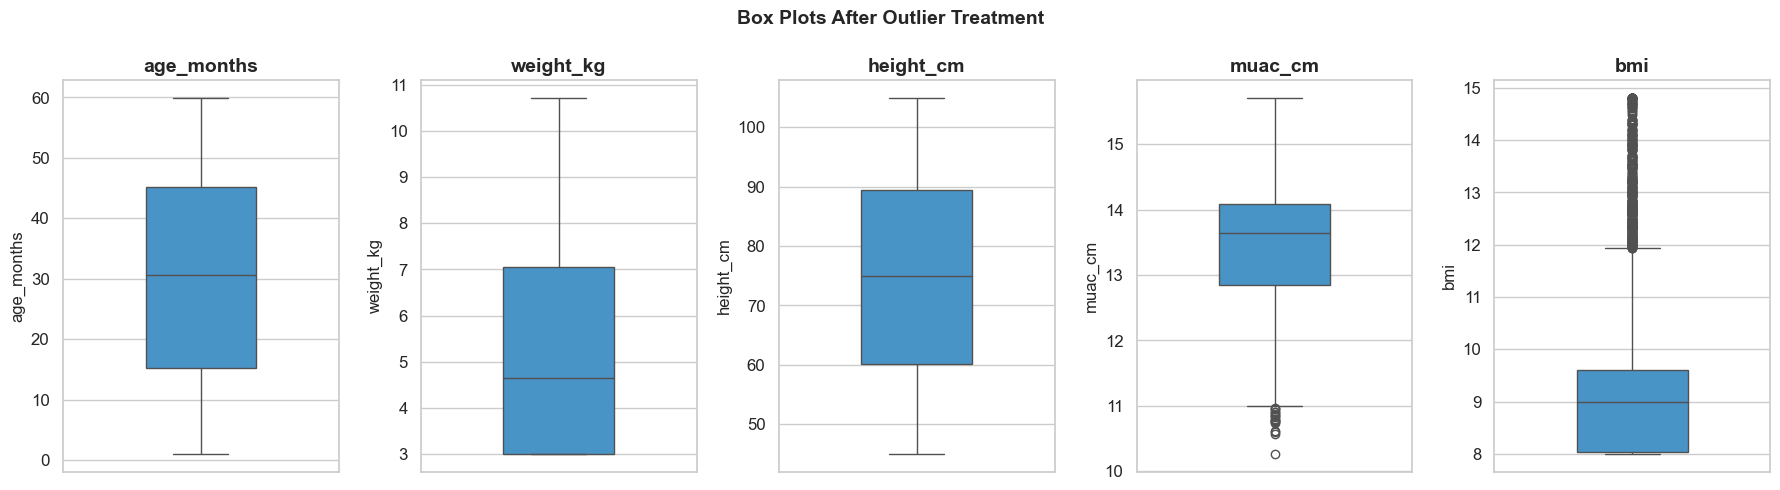

In [21]:
# ── Handling: Winsorise (cap) at physiological bounds ──────────────────
# Strategy: Cap values at physiological bounds instead of deleting rows
# This preserves sample size (critical for the small 'severe' class)

print('\n=== OUTLIER HANDLING (Winsorisation) ===')
before = len(df)
total_capped = 0

for col, (lo, hi) in VALID_RANGES.items():
    if col not in df.columns:
        continue
    below = (df[col] < lo).sum()
    above = (df[col] > hi).sum()
    capped = below + above
    
    if capped > 0:
        df[col] = df[col].clip(lower=lo, upper=hi)
        total_capped += capped
        print(f'  {col}: capped {below} below {lo}, {above} above {hi}')

if total_capped == 0:
    print('  No values needed capping — all within physiological bounds.')
else:
    print(f'\n  Total values capped: {total_capped}')

log_step('Winsorise outliers', before, len(df), f'{total_capped} values capped at physiological bounds')

# ── Visualise outliers with box plots ─────────────────────────────────
fig, axes = plt.subplots(1, len(feature_cols), figsize=(18, 5))
for i, col in enumerate(feature_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color='#3498db', width=0.4)
    axes[i].set_title(col, fontweight='bold')
fig.suptitle('Box Plots After Outlier Treatment', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join('dataset', 'boxplots_after_cleaning.png'), dpi=150, bbox_inches='tight')
plt.show()

## 2.4 Data Type Corrections

In [22]:
# ── Data type corrections ─────────────────────────────────────────────
print('=== DATA TYPE CORRECTIONS ===')

# Round age_months to nearest integer
df['age_months'] = df['age_months'].round(0).astype(int)
print('✅ age_months → rounded to integer')

# Ensure numeric columns are float64
for col in ['weight_kg', 'height_cm', 'muac_cm', 'bmi']:
    df[col] = df[col].astype('float64')
print('✅ Numeric columns → float64')

# Standardise column names (already lowercase with underscores)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print('✅ Column names standardised')

print(f'\nFinal dtypes:')
print(df.dtypes)

=== DATA TYPE CORRECTIONS ===
✅ age_months → rounded to integer
✅ Numeric columns → float64
✅ Column names standardised

Final dtypes:
age_months            int32
weight_kg           float64
height_cm           float64
muac_cm             float64
bmi                 float64
nutrition_status     object
bmi_original        float64
dtype: object


## 2.5 Label Encoding

In [23]:
# ── Label encoding for the target variable ────────────────────────────
# The dataset labels are: normal, moderate, severe
# We encode them as ordinal values reflecting severity:
#   normal → 0, moderate → 1, severe → 2
#
# NOTE: The adviceTemplates.js uses a different schema:
#   0=Underweight, 1=Normal, 2=Overweight
# A mapping layer will be needed in the integration step (Task 7)
# to translate model predictions to advice engine keys.

LABEL_MAP = {'normal': 0, 'moderate': 1, 'severe': 2}
LABEL_MAP_INVERSE = {v: k for k, v in LABEL_MAP.items()}

df['nutrition_status_original'] = df['nutrition_status']  # preserve original
df['nutrition_status_encoded'] = df['nutrition_status'].map(LABEL_MAP)

# Verify encoding
print('=== LABEL ENCODING ===')
print(f'Mapping: {LABEL_MAP}')
print(f'\nEncoded distribution:')
print(df['nutrition_status_encoded'].value_counts().sort_index())

unmapped = df['nutrition_status_encoded'].isnull().sum()
if unmapped > 0:
    print(f'❌ {unmapped} rows could not be mapped!')
    print(df[df['nutrition_status_encoded'].isnull()]['nutrition_status'].unique())
else:
    print('✅ All labels successfully encoded')

=== LABEL ENCODING ===
Mapping: {'normal': 0, 'moderate': 1, 'severe': 2}

Encoded distribution:
nutrition_status_encoded
0    3550
1    1100
2     350
Name: count, dtype: int64
✅ All labels successfully encoded


## 2.6 Remove Duplicate Rows

In [24]:
# ── Remove exact duplicates ───────────────────────────────────────────
before = len(df)
df.drop_duplicates(subset=feature_cols + ['nutrition_status'], keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)
log_step('Remove duplicates', before, len(df), 'Exact duplicates on features + label')

  [Remove duplicates] 5000 → 5000 rows (0 removed). Exact duplicates on features + label


## 2.7 Allergy Data Cleaning

In [25]:
# ── Clean the allergy dataset ─────────────────────────────────────────
print('=== ALLERGY DATA CLEANING ===')

# Step 1: Filter to ages 0–6 only
df_allergy = df_allergy_raw[df_allergy_raw['AGE_START_YEARS'] <= 6].copy()
print(f'1. Filtered to ages 0–6: {len(df_allergy):,} rows')

# Step 2: Create binary allergy flags
# NA in _ALG_START means "no allergy recorded" → binary 0
allergen_start_cols = [c for c in df_allergy.columns if c.endswith('_ALG_START')]
allergen_names = [c.replace('_ALG_START', '').lower() for c in allergen_start_cols]

for col, name in zip(allergen_start_cols, allergen_names):
    df_allergy[f'has_{name}_allergy'] = df_allergy[col].notna().astype(int)

allergy_flag_cols = [f'has_{name}_allergy' for name in allergen_names]
print(f'2. Created {len(allergy_flag_cols)} binary allergy flags')

# Step 3: Create summary features per child
df_allergy['total_allergies'] = df_allergy[allergy_flag_cols].sum(axis=1)
df_allergy['has_any_allergy'] = (df_allergy['total_allergies'] > 0).astype(int)
print(f'3. Created total_allergies and has_any_allergy summary columns')

# Step 4: Select relevant columns for clean output
keep_cols = (
    ['SUBJECT_ID', 'BIRTH_YEAR', 'GENDER_FACTOR', 'RACE_FACTOR', 
     'ETHNICITY_FACTOR', 'AGE_START_YEARS', 'AGE_END_YEARS',
     'ATOPIC_MARCH_COHORT', 'total_allergies', 'has_any_allergy']
    + allergy_flag_cols
)
df_allergy_clean = df_allergy[keep_cols].copy()

# Step 5: Drop allergen columns with <1% prevalence (too rare for analysis)
rare_threshold = 0.01
dropped_rare = []
for col in allergy_flag_cols:
    prevalence = df_allergy_clean[col].mean()
    if prevalence < rare_threshold:
        dropped_rare.append(col)
        df_allergy_clean.drop(columns=[col], inplace=True)

if dropped_rare:
    print(f'4. Dropped {len(dropped_rare)} rare allergens (<{rare_threshold*100}% prevalence):')
    for col in dropped_rare:
        print(f'   - {col}')
else:
    print(f'4. No rare allergens dropped (all above {rare_threshold*100}% prevalence)')

# Step 6: Remove duplicates
before_dup = len(df_allergy_clean)
df_allergy_clean.drop_duplicates(subset=['SUBJECT_ID'], keep='first', inplace=True)
df_allergy_clean.reset_index(drop=True, inplace=True)
print(f'5. Removed {before_dup - len(df_allergy_clean)} duplicate subjects')

print(f'\n✅ Clean allergy dataset: {len(df_allergy_clean)} subjects × {len(df_allergy_clean.columns)} columns')
print(f'\nAllergy prevalence summary (ages 0–6):')
remaining_flags = [c for c in df_allergy_clean.columns if c.startswith('has_') and c.endswith('_allergy') and c != 'has_any_allergy']
for col in remaining_flags:
    pct = df_allergy_clean[col].mean() * 100
    print(f'  {col:<30} {pct:>5.2f}%')

=== ALLERGY DATA CLEANING ===
1. Filtered to ages 0–6: 233,495 rows
2. Created 16 binary allergy flags
3. Created total_allergies and has_any_allergy summary columns


4. Dropped 12 rare allergens (<1.0% prevalence):
   - has_fish_allergy
   - has_soy_allergy
   - has_wheat_allergy
   - has_sesame_allergy
   - has_treenut_allergy
   - has_walnut_allergy
   - has_pecan_allergy
   - has_pistach_allergy
   - has_almond_allergy
   - has_brazil_allergy
   - has_hazelnut_allergy
   - has_cashew_allergy
5. Removed 0 duplicate subjects

✅ Clean allergy dataset: 233495 subjects × 14 columns

Allergy prevalence summary (ages 0–6):
  has_shellfish_allergy           1.46%
  has_milk_allergy                2.82%
  has_egg_allergy                 2.37%
  has_peanut_allergy              3.07%


## 2.8 Save Cleaned Datasets

In [26]:
# ── Save cleaned malnutrition dataset ─────────────────────────────────
# Select final columns for the clean output
clean_cols = ['age_months', 'weight_kg', 'height_cm', 'muac_cm', 'bmi',
              'nutrition_status', 'nutrition_status_encoded']

# Keep bmi_original only if there were mismatches
if 'bmi_original' in df.columns:
    clean_cols.append('bmi_original')

df_clean = df[clean_cols].copy()
df_clean.to_csv(CLEAN_OUTPUT_PATH, index=False)
print(f'✅ Saved clean malnutrition data: {CLEAN_OUTPUT_PATH}')
print(f'   Rows: {len(df_clean):,} | Columns: {len(df_clean.columns)}')

# Save cleaned allergy data
df_allergy_clean.to_csv(CLEAN_ALLERGY_OUTPUT_PATH, index=False)
print(f'\n✅ Saved clean allergy data: {CLEAN_ALLERGY_OUTPUT_PATH}')
print(f'   Rows: {len(df_allergy_clean):,} | Columns: {len(df_allergy_clean.columns)}')

✅ Saved clean malnutrition data: dataset\cleaned_malnutrition_data.csv
   Rows: 5,000 | Columns: 8



✅ Saved clean allergy data: dataset\cleaned_allergy_data.csv
   Rows: 233,495 | Columns: 14


## 2.9 Cleaning Log

In [27]:
# ── Print full cleaning log ───────────────────────────────────────────
print('=== DATA CLEANING LOG ===')
print(f'{"Step":<25} {"Before":>8} {"After":>8} {"Removed":>8}  Details')
print('-' * 85)
for entry in cleaning_log:
    print(f'{entry["Step"]:<25} {entry["Before"]:>8} {entry["After"]:>8} {entry["Removed"]:>8}  {entry["Details"]}')

print(f'\n--- Summary ---')
print(f'Initial rows:   {initial_rows:,}')
print(f'Final rows:     {len(df_clean):,}')
print(f'Total removed:  {initial_rows - len(df_clean):,} ({(initial_rows - len(df_clean))/initial_rows*100:.2f}%)')
print(f'Retention rate: {len(df_clean)/initial_rows*100:.2f}%')

=== DATA CLEANING LOG ===
Step                        Before    After  Removed  Details
-------------------------------------------------------------------------------------
Drop missing labels           5000     5000        0  Target label must never be missing
Drop >50% missing             5000     5000        0  Rows with more than half features missing
Winsorise outliers            5000     5000        0  1205 values capped at physiological bounds
Remove duplicates             5000     5000        0  Exact duplicates on features + label

--- Summary ---
Initial rows:   5,000
Final rows:     5,000
Total removed:  0 (0.00%)
Retention rate: 100.00%


---
# TASK 3 — Exploratory Data Analysis (EDA)
---

## 3.1 Univariate Analysis — Feature Distributions

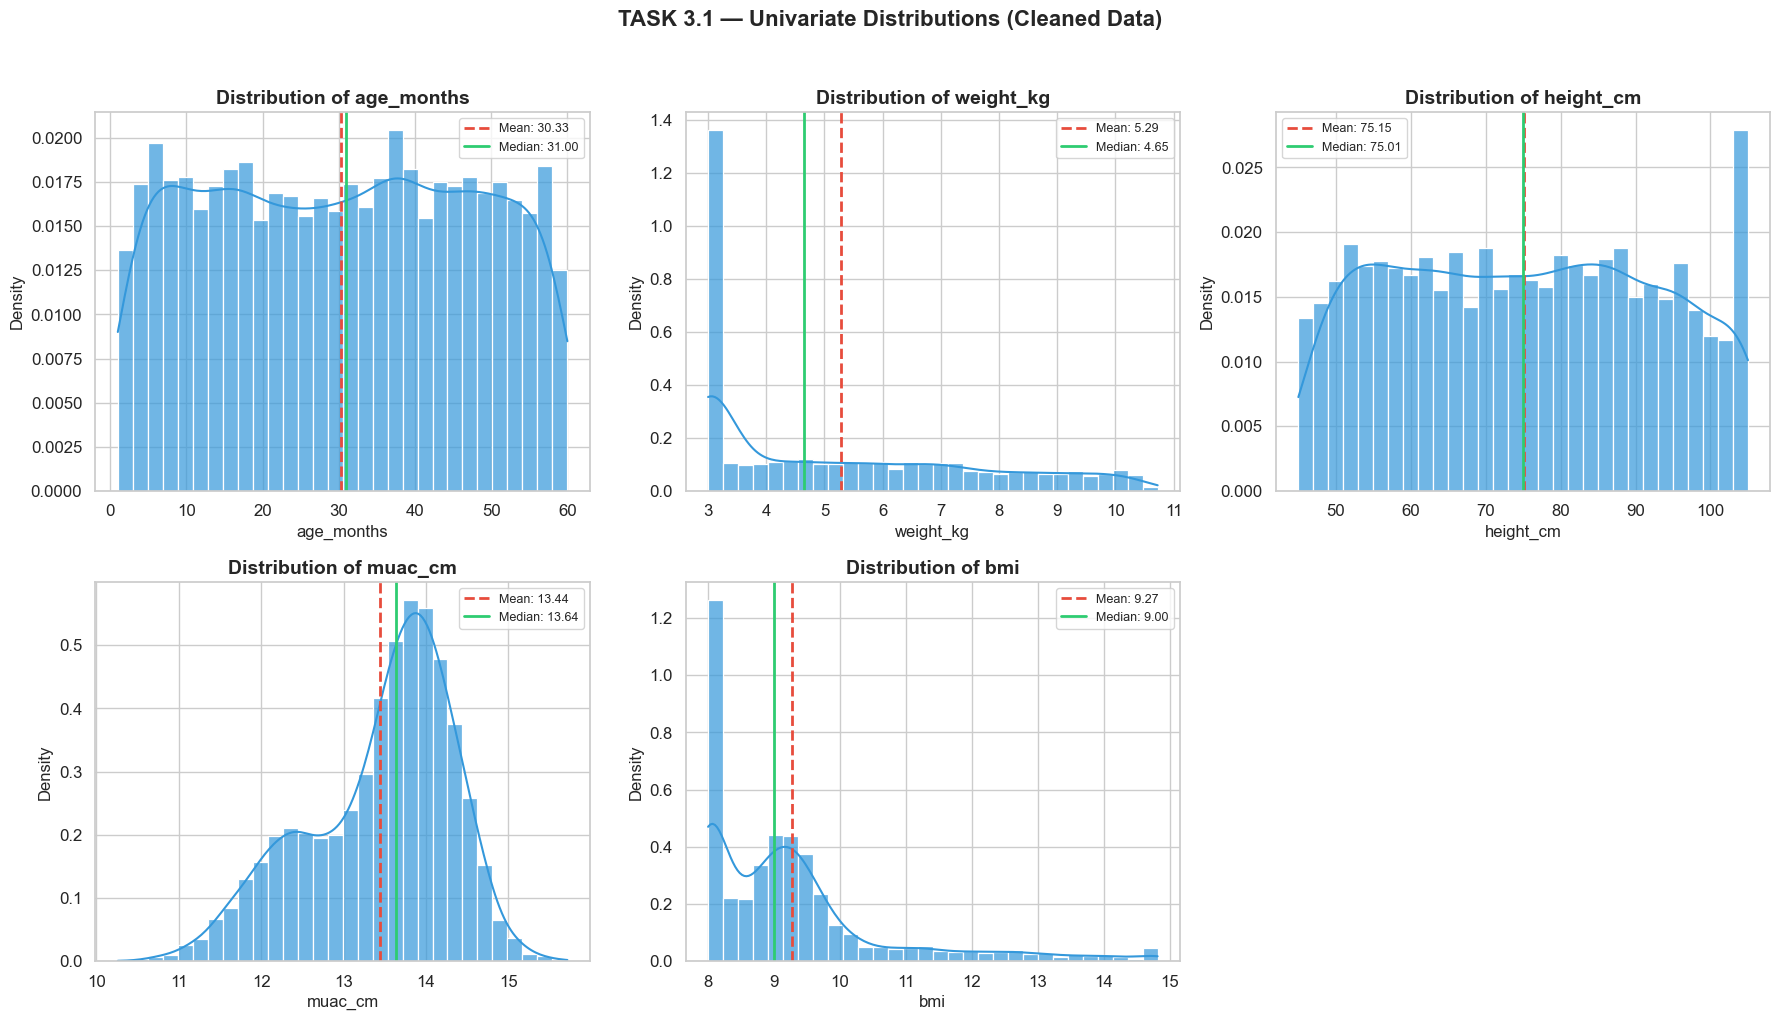

In [28]:
# ── Histogram + KDE for each numeric feature ─────────────────────────
feature_cols = ['age_months', 'weight_kg', 'height_cm', 'muac_cm', 'bmi']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    sns.histplot(df_clean[col], kde=True, ax=ax, color='#3498db', edgecolor='white',
                 stat='density', alpha=0.7, bins=30)
    
    # Add mean and median lines
    mean_val = df_clean[col].mean()
    median_val = df_clean[col].median()
    ax.axvline(mean_val, color='#e74c3c', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='#2ecc71', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
    
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.legend(fontsize=9)

# Remove unused subplot
axes[-1].set_visible(False)

fig.suptitle('TASK 3.1 — Univariate Distributions (Cleaned Data)', fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join('dataset', 'eda_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3.2 Univariate Analysis — Box Plots by Class

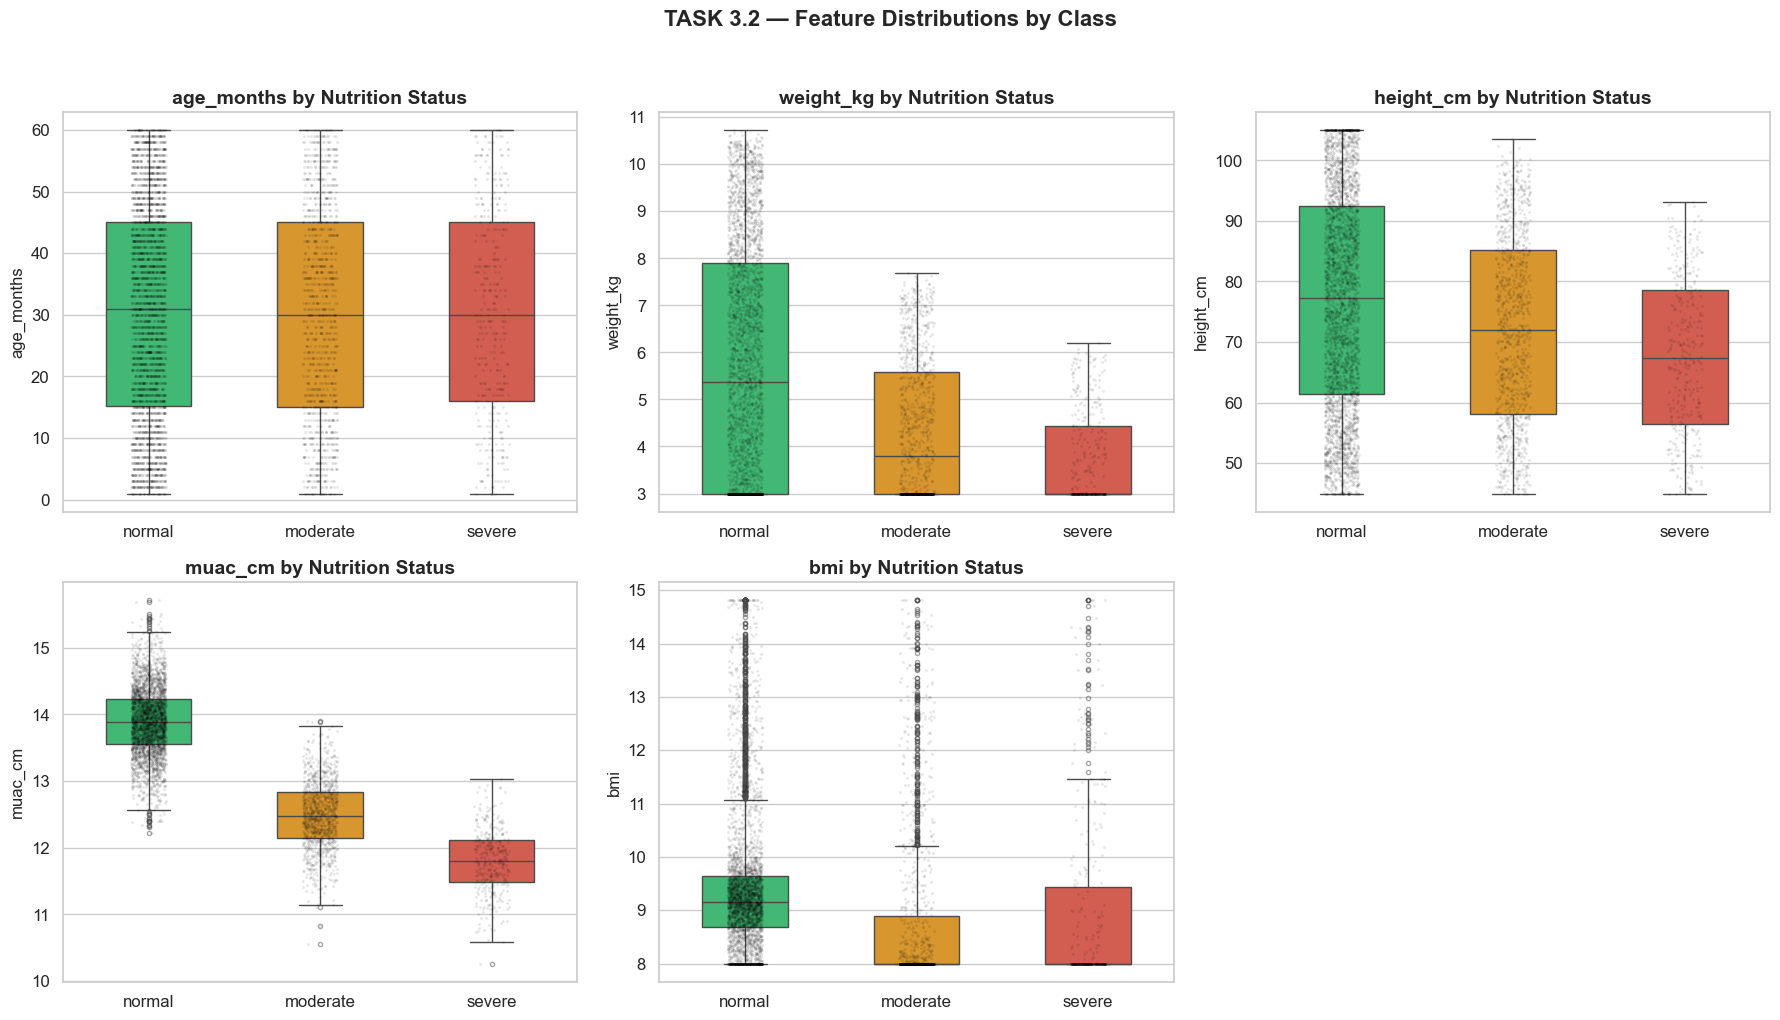

In [29]:
# ── Box plots grouped by nutrition_status ─────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

palette = {'normal': '#2ecc71', 'moderate': '#f39c12', 'severe': '#e74c3c'}
order = ['normal', 'moderate', 'severe']

for i, col in enumerate(feature_cols):
    ax = axes[i]
    sns.boxplot(
        data=df_clean, x='nutrition_status', y=col,
        order=order, palette=palette, ax=ax,
        width=0.5, flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.5}
    )
    # Overlay strip plot for individual data points
    sns.stripplot(
        data=df_clean, x='nutrition_status', y=col,
        order=order, ax=ax, color='black', alpha=0.1, size=2, jitter=True
    )
    ax.set_title(f'{col} by Nutrition Status', fontweight='bold')
    ax.set_xlabel('')

axes[-1].set_visible(False)

fig.suptitle('TASK 3.2 — Feature Distributions by Class', fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join('dataset', 'eda_boxplots_by_class.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3.3 Bivariate Analysis — Correlation Matrix

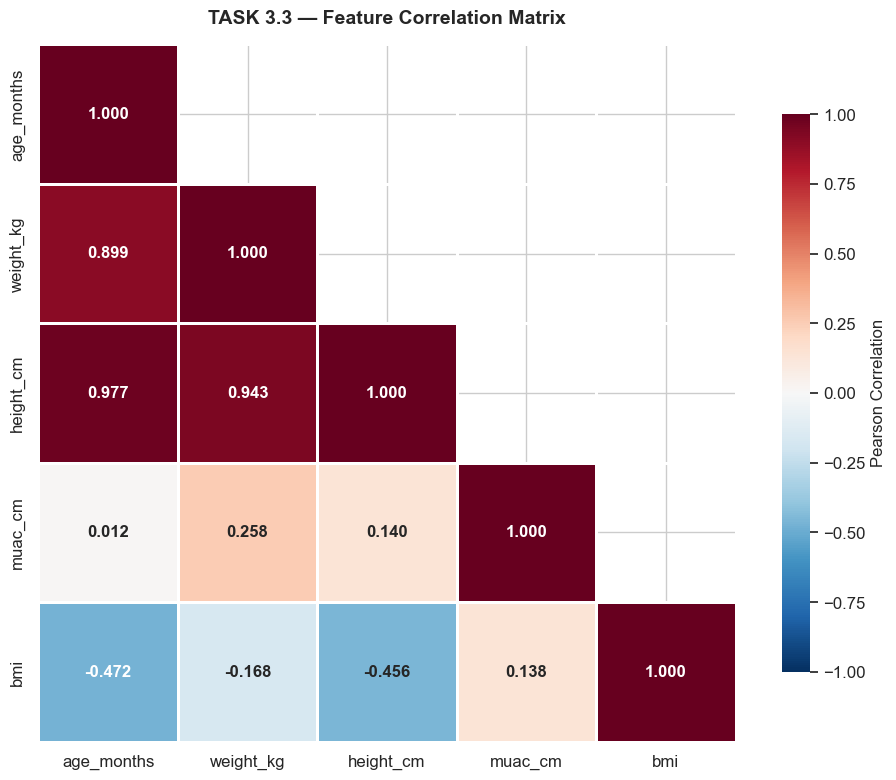

=== HIGH CORRELATION PAIRS (|r| > 0.8) ===
  ⚠️  age_months ↔ weight_kg: r = 0.899
  ⚠️  age_months ↔ height_cm: r = 0.977
  ⚠️  weight_kg ↔ height_cm: r = 0.943


In [30]:
# ── Pearson correlation heatmap ───────────────────────────────────────
corr_matrix = df_clean[feature_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.3f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=1, ax=ax,
    annot_kws={'size': 12, 'fontweight': 'bold'},
    cbar_kws={'shrink': 0.8, 'label': 'Pearson Correlation'}
)
ax.set_title('TASK 3.3 — Feature Correlation Matrix', fontweight='bold', fontsize=14, pad=15)

plt.tight_layout()
plt.savefig(os.path.join('dataset', 'eda_correlation_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# Report highly correlated pairs
print('=== HIGH CORRELATION PAIRS (|r| > 0.8) ===')
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.8:
            print(f'  ⚠️  {feature_cols[i]} ↔ {feature_cols[j]}: r = {r:.3f}')

## 3.4 Bivariate Analysis — Pair Plot

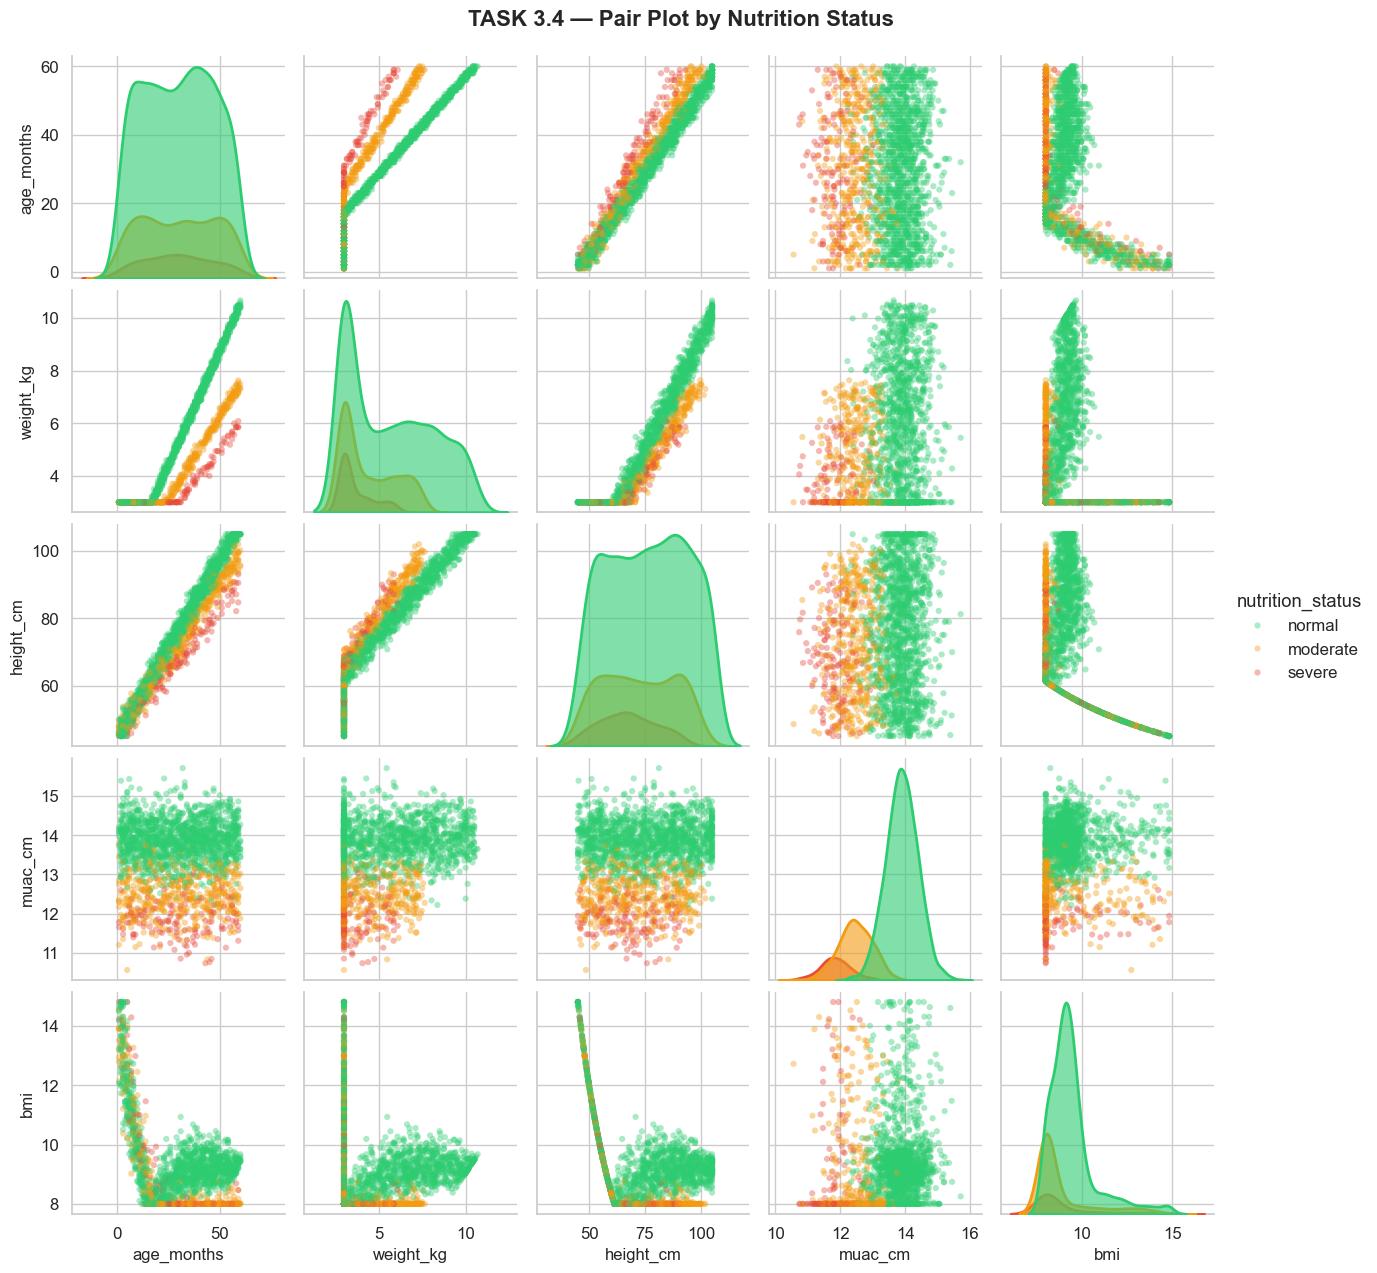

In [31]:
# ── Pair plot coloured by nutrition_status ─────────────────────────────
# Subsample for performance if dataset is very large
n_sample = min(2000, len(df_clean))
df_sample = df_clean.sample(n=n_sample, random_state=42) if len(df_clean) > n_sample else df_clean

g = sns.pairplot(
    df_sample, vars=feature_cols, hue='nutrition_status',
    hue_order=['normal', 'moderate', 'severe'],
    palette=palette, diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 20, 'edgecolor': 'none'},
    diag_kws={'alpha': 0.6, 'linewidth': 2}
)
g.figure.suptitle('TASK 3.4 — Pair Plot by Nutrition Status', fontweight='bold', fontsize=16, y=1.02)

plt.savefig(os.path.join('dataset', 'eda_pairplot.png'), dpi=100, bbox_inches='tight')
plt.show()

## 3.5 Bivariate — BMI vs Weight & Height (Verification)

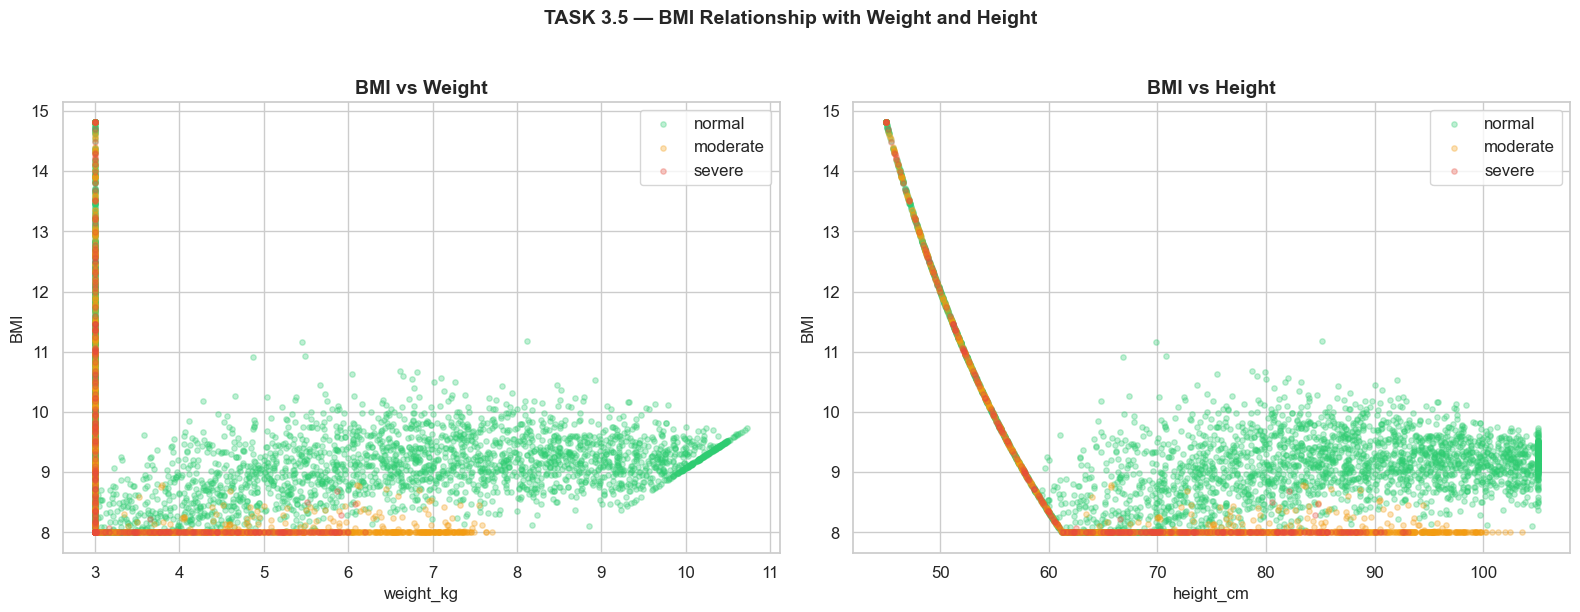

In [32]:
# ── BMI vs Weight/Height scatter ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (x_col, title) in enumerate([('weight_kg', 'BMI vs Weight'), ('height_cm', 'BMI vs Height')]):
    ax = axes[i]
    for status in ['normal', 'moderate', 'severe']:
        subset = df_clean[df_clean['nutrition_status'] == status]
        ax.scatter(subset[x_col], subset['bmi'], alpha=0.3, s=15,
                   color=palette[status], label=status)
    ax.set_xlabel(x_col)
    ax.set_ylabel('BMI')
    ax.set_title(title, fontweight='bold')
    ax.legend()

fig.suptitle('TASK 3.5 — BMI Relationship with Weight and Height', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join('dataset', 'eda_bmi_verification.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3.6 Age-Stratified Analysis

In [33]:
# ── Age group analysis ────────────────────────────────────────────────
# Define age bands relevant to tadika context
age_bins = [0, 12, 24, 48, 72]
age_labels = ['0–12m (Infant)', '12–24m (Young Toddler)', '24–48m (Toddler)', '48–72m (Preschool)']
df_clean['age_group'] = pd.cut(df_clean['age_months'], bins=age_bins, labels=age_labels, right=True)

print('=== AGE GROUP DISTRIBUTION ===')
age_class_ct = pd.crosstab(df_clean['age_group'], df_clean['nutrition_status'], margins=True)
print(age_class_ct)

# Normalised percentages
print('\n--- % of each class within age group ---')
age_class_pct = pd.crosstab(df_clean['age_group'], df_clean['nutrition_status'], normalize='index') * 100
print(age_class_pct.round(1))

=== AGE GROUP DISTRIBUTION ===
nutrition_status        moderate  normal  severe   All
age_group                                             
0–12m (Infant)               224     711      69  1004
12–24m (Young Toddler)       229     713      71  1013
24–48m (Toddler)             440    1441     143  2024
48–72m (Preschool)           207     685      67   959
All                         1100    3550     350  5000

--- % of each class within age group ---
nutrition_status        moderate  normal  severe
age_group                                       
0–12m (Infant)           22.3000 70.8000  6.9000
12–24m (Young Toddler)   22.6000 70.4000  7.0000
24–48m (Toddler)         21.7000 71.2000  7.1000
48–72m (Preschool)       21.6000 71.4000  7.0000


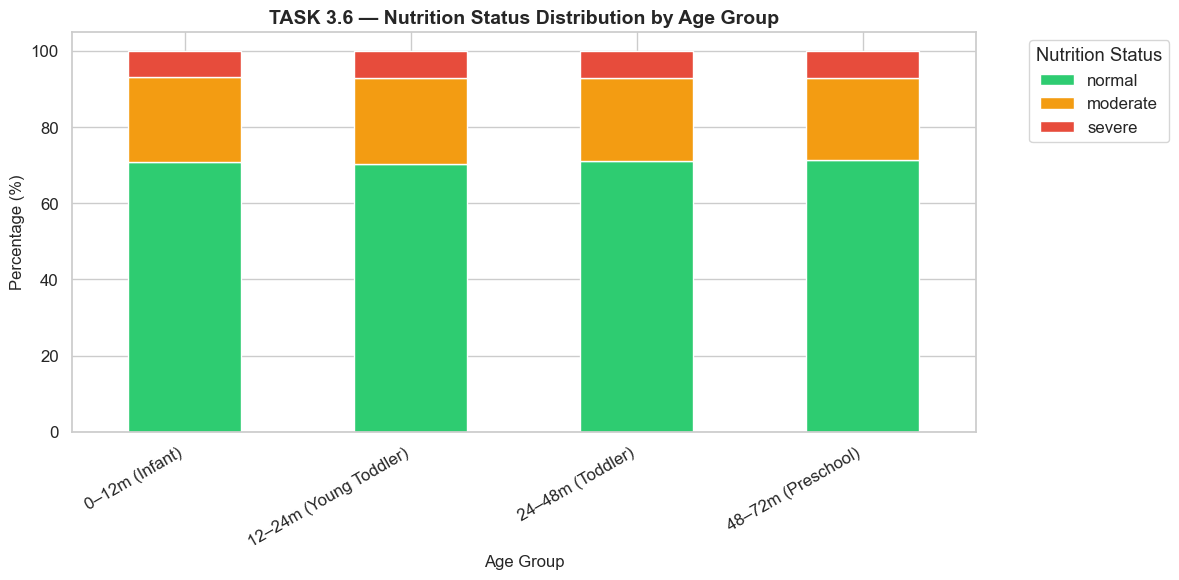

In [34]:
# ── Stacked bar chart: class distribution by age group ────────────────
fig, ax = plt.subplots(figsize=(12, 6))

age_class_pct[['normal', 'moderate', 'severe']].plot(
    kind='bar', stacked=True, ax=ax,
    color=[palette['normal'], palette['moderate'], palette['severe']],
    edgecolor='white', linewidth=1
)

ax.set_title('TASK 3.6 — Nutrition Status Distribution by Age Group', fontweight='bold', fontsize=14)
ax.set_xlabel('Age Group')
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Nutrition Status', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(os.path.join('dataset', 'eda_age_group_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3.7 MUAC as Malnutrition Indicator

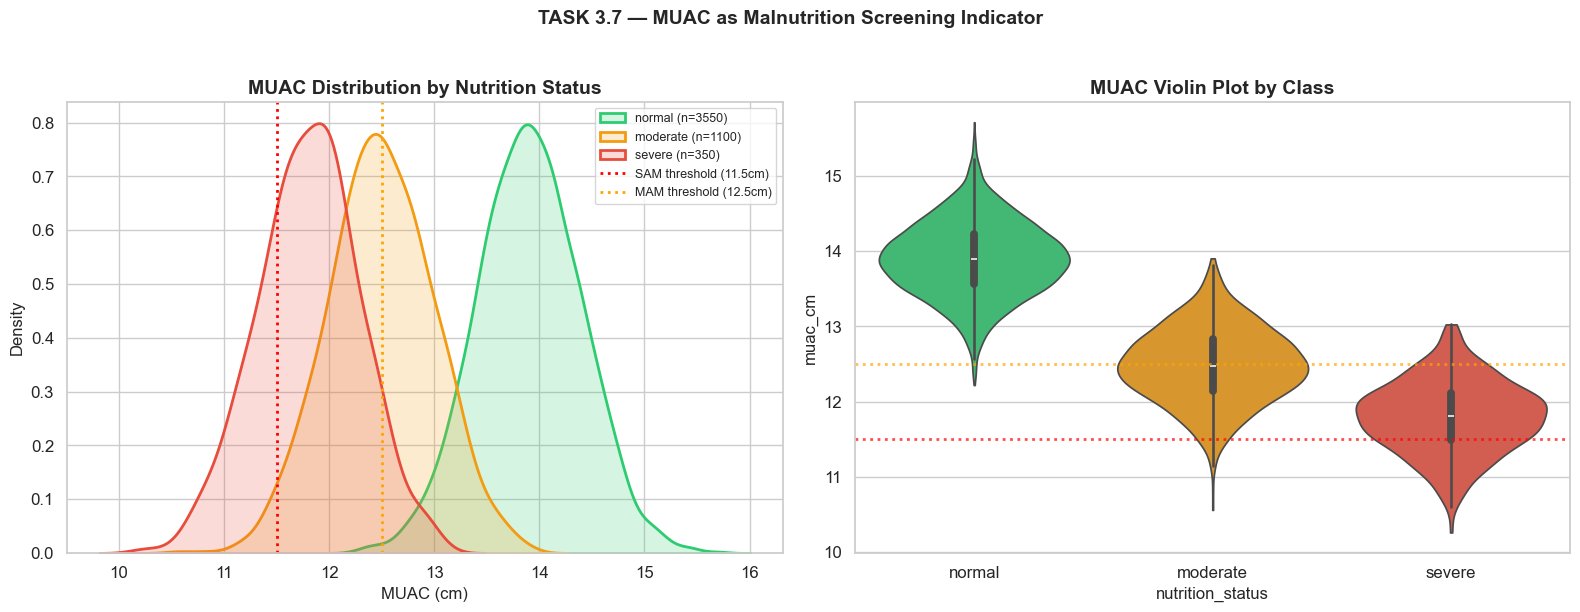

In [35]:
# ── MUAC discriminative power analysis ────────────────────────────────
# MUAC (Mid-Upper Arm Circumference) is a WHO-recognised field screening tool.
# WHO thresholds for children 6–60 months:
#   - MUAC < 11.5 cm → Severe Acute Malnutrition (SAM)
#   - MUAC 11.5–12.5 cm → Moderate Acute Malnutrition (MAM)
#   - MUAC ≥ 12.5 cm → Normal

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# KDE plot
ax = axes[0]
for status in ['normal', 'moderate', 'severe']:
    subset = df_clean[df_clean['nutrition_status'] == status]
    sns.kdeplot(subset['muac_cm'], ax=ax, color=palette[status],
                label=f'{status} (n={len(subset)})', linewidth=2, fill=True, alpha=0.2)

# Add WHO thresholds
ax.axvline(11.5, color='red', linestyle=':', linewidth=2, label='SAM threshold (11.5cm)')
ax.axvline(12.5, color='orange', linestyle=':', linewidth=2, label='MAM threshold (12.5cm)')
ax.set_title('MUAC Distribution by Nutrition Status', fontweight='bold')
ax.set_xlabel('MUAC (cm)')
ax.legend(fontsize=9)

# Violin plot
ax = axes[1]
sns.violinplot(
    data=df_clean, x='nutrition_status', y='muac_cm',
    order=['normal', 'moderate', 'severe'], palette=palette,
    ax=ax, inner='box', cut=0
)
ax.axhline(11.5, color='red', linestyle=':', linewidth=2, alpha=0.7)
ax.axhline(12.5, color='orange', linestyle=':', linewidth=2, alpha=0.7)
ax.set_title('MUAC Violin Plot by Class', fontweight='bold')

fig.suptitle('TASK 3.7 — MUAC as Malnutrition Screening Indicator', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join('dataset', 'eda_muac_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3.8 Feature Importance (Preliminary)

In [36]:
# ── ANOVA F-scores ────────────────────────────────────────────────────
from sklearn.feature_selection import f_classif, mutual_info_classif

X = df_clean[feature_cols].values
y = df_clean['nutrition_status_encoded'].values

# ANOVA F-scores
f_scores, p_values = f_classif(X, y)

# Mutual information
mi_scores = mutual_info_classif(X, y, random_state=42)

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'ANOVA F-Score': f_scores,
    'ANOVA p-value': p_values,
    'Mutual Information': mi_scores
}).sort_values('ANOVA F-Score', ascending=False)

print('=== PRELIMINARY FEATURE IMPORTANCE ===')
print(importance_df.to_string(index=False))

# Significance check
print('\n--- Significance (α = 0.05) ---')
for _, row in importance_df.iterrows():
    sig = '✅ Significant' if row['ANOVA p-value'] < 0.05 else '❌ Not significant'
    print(f'  {row["Feature"]:<15} p = {row["ANOVA p-value"]:.2e}  {sig}')

=== PRELIMINARY FEATURE IMPORTANCE ===
   Feature  ANOVA F-Score  ANOVA p-value  Mutual Information
   muac_cm      5449.5256         0.0000              0.4998
 weight_kg       251.8233         0.0000              0.0931
       bmi        77.4971         0.0000              0.1808
 height_cm        69.5621         0.0000              0.0435
age_months         0.2812         0.7549              0.0058

--- Significance (α = 0.05) ---
  muac_cm         p = 0.00e+00  ✅ Significant
  weight_kg       p = 6.33e-105  ✅ Significant
  bmi             p = 7.16e-34  ✅ Significant
  height_cm       p = 1.59e-30  ✅ Significant
  age_months      p = 7.55e-01  ❌ Not significant


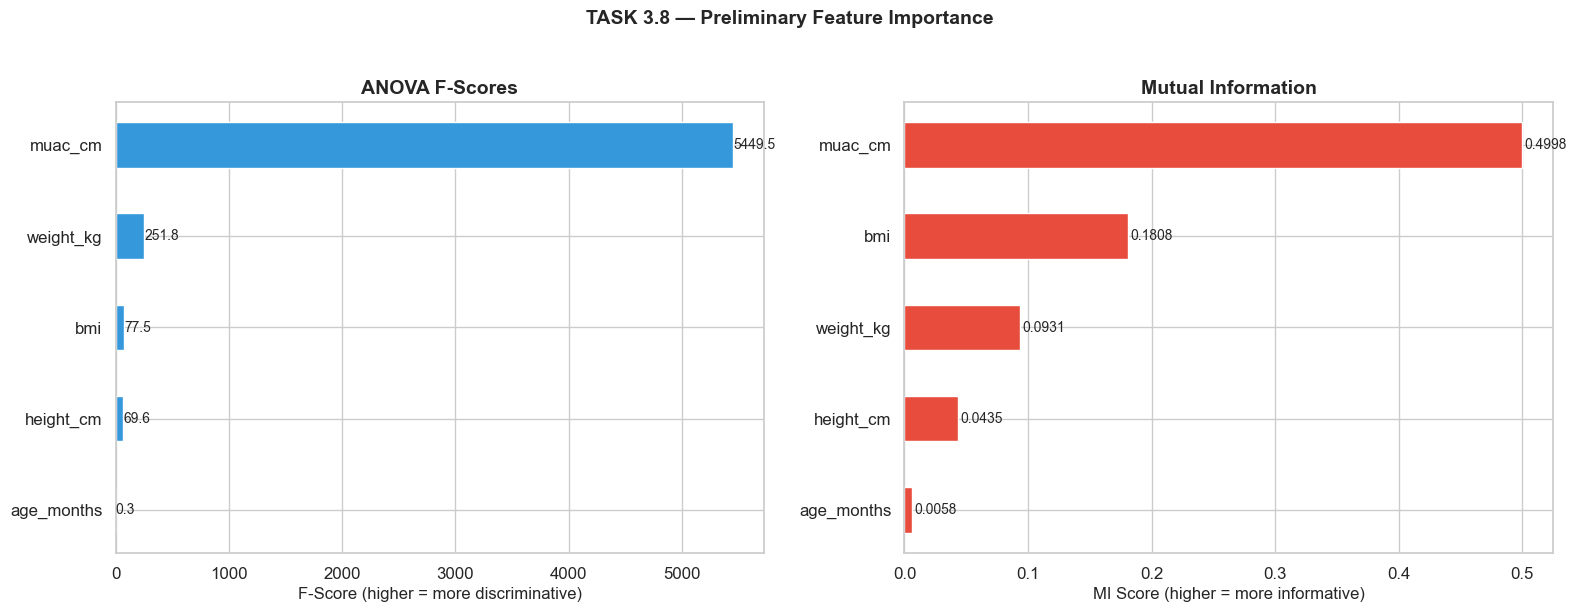

In [37]:
# ── Visualise feature importance ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ANOVA F-scores
importance_sorted = importance_df.sort_values('ANOVA F-Score', ascending=True)
axes[0].barh(importance_sorted['Feature'], importance_sorted['ANOVA F-Score'],
             color='#3498db', edgecolor='white', height=0.5)
axes[0].set_title('ANOVA F-Scores', fontweight='bold')
axes[0].set_xlabel('F-Score (higher = more discriminative)')
for i, (_, row) in enumerate(importance_sorted.iterrows()):
    axes[0].text(row['ANOVA F-Score'] + 0.5, i,
                 f'{row["ANOVA F-Score"]:.1f}', va='center', fontsize=10)

# Mutual Information
mi_sorted = importance_df.sort_values('Mutual Information', ascending=True)
axes[1].barh(mi_sorted['Feature'], mi_sorted['Mutual Information'],
             color='#e74c3c', edgecolor='white', height=0.5)
axes[1].set_title('Mutual Information', fontweight='bold')
axes[1].set_xlabel('MI Score (higher = more informative)')
for i, (_, row) in enumerate(mi_sorted.iterrows()):
    axes[1].text(row['Mutual Information'] + 0.002, i,
                 f'{row["Mutual Information"]:.4f}', va='center', fontsize=10)

fig.suptitle('TASK 3.8 — Preliminary Feature Importance', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join('dataset', 'eda_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3.9 Allergy Data EDA

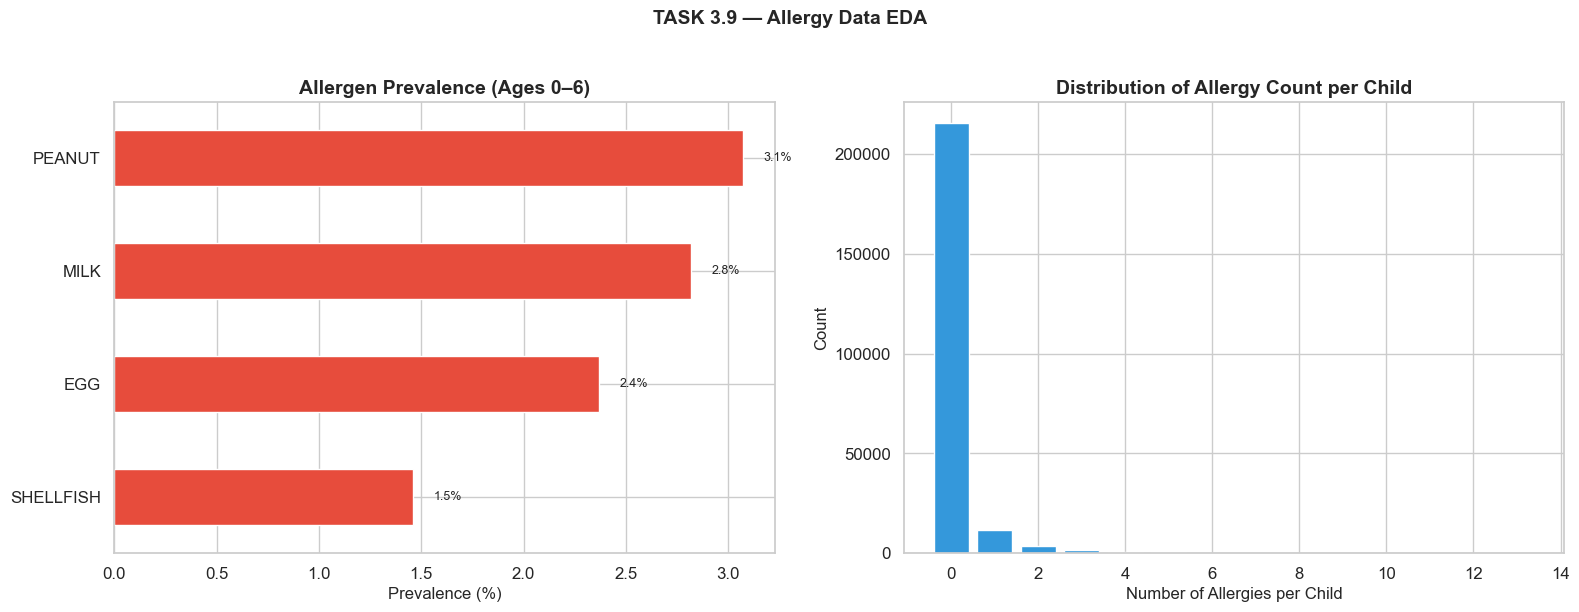

Children with any allergy: 18,127 (7.8%)
Children with no allergies: 215,368
Mean allergies per child: 0.13
Max allergies per child: 13


In [38]:
# ── Allergy prevalence bar chart ──────────────────────────────────────
remaining_flags = [c for c in df_allergy_clean.columns if c.startswith('has_') and c.endswith('_allergy') and c != 'has_any_allergy']
prevalence_data = df_allergy_clean[remaining_flags].mean().sort_values(ascending=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of prevalence
ax = axes[0]
prevalence_data.plot(kind='barh', ax=ax, color='#e74c3c', edgecolor='white')
ax.set_xlabel('Prevalence (%)')
ax.set_title('Allergen Prevalence (Ages 0–6)', fontweight='bold')
ax.set_yticklabels([l.replace('has_', '').replace('_allergy', '').upper() for l in prevalence_data.index])
for i, v in enumerate(prevalence_data.values):
    ax.text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=9)

# Total allergies distribution
ax = axes[1]
allergy_counts = df_allergy_clean['total_allergies'].value_counts().sort_index()
ax.bar(allergy_counts.index, allergy_counts.values, color='#3498db', edgecolor='white')
ax.set_xlabel('Number of Allergies per Child')
ax.set_ylabel('Count')
ax.set_title('Distribution of Allergy Count per Child', fontweight='bold')

fig.suptitle('TASK 3.9 — Allergy Data EDA', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join('dataset', 'eda_allergy_prevalence.png'), dpi=150, bbox_inches='tight')
plt.show()

# Stats
print(f'Children with any allergy: {df_allergy_clean["has_any_allergy"].sum():,} ({df_allergy_clean["has_any_allergy"].mean()*100:.1f}%)')
print(f'Children with no allergies: {(df_allergy_clean["has_any_allergy"]==0).sum():,}')
print(f'Mean allergies per child: {df_allergy_clean["total_allergies"].mean():.2f}')
print(f'Max allergies per child: {df_allergy_clean["total_allergies"].max()}')

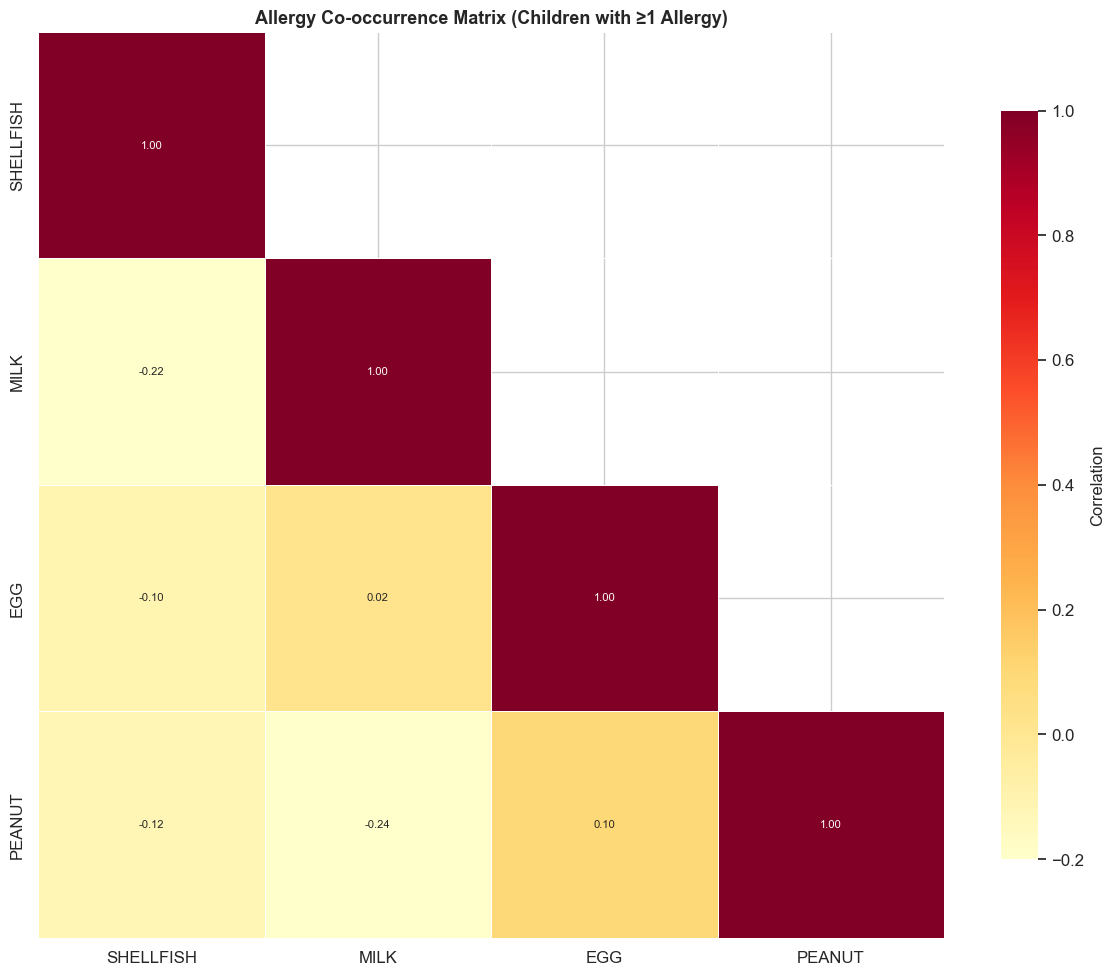

In [39]:
# ── Allergy co-occurrence heatmap ─────────────────────────────────────
# Only for children who have at least one allergy
df_with_allergy = df_allergy_clean[df_allergy_clean['has_any_allergy'] == 1]

if len(remaining_flags) >= 2 and len(df_with_allergy) > 0:
    cooccurrence = df_with_allergy[remaining_flags].corr()
    
    # Clean labels
    clean_labels = [l.replace('has_', '').replace('_allergy', '').upper() for l in remaining_flags]
    cooccurrence.index = clean_labels
    cooccurrence.columns = clean_labels
    
    fig, ax = plt.subplots(figsize=(12, 10))
    mask = np.triu(np.ones_like(cooccurrence, dtype=bool), k=1)
    sns.heatmap(
        cooccurrence, mask=mask, annot=True, fmt='.2f',
        cmap='YlOrRd', vmin=-0.2, vmax=1.0,
        square=True, linewidths=0.5, ax=ax,
        annot_kws={'size': 8},
        cbar_kws={'shrink': 0.8, 'label': 'Correlation'}
    )
    ax.set_title('Allergy Co-occurrence Matrix (Children with ≥1 Allergy)', fontweight='bold', fontsize=13)
    
    plt.tight_layout()
    plt.savefig(os.path.join('dataset', 'eda_allergy_cooccurrence.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Insufficient data for co-occurrence analysis.')

=== ALLERGY PREVALENCE BY GENDER ===
               With Allergy   Total  Prevalence %
GENDER_FACTOR                                    
S0 - Male             10493  119893        8.7500
S1 - Female            7634  113602        6.7200


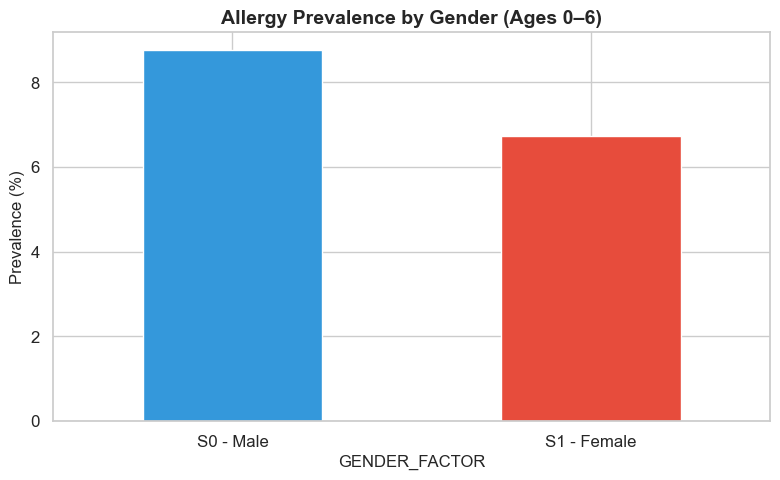

In [40]:
# ── Allergy prevalence by gender ──────────────────────────────────────
if 'GENDER_FACTOR' in df_allergy_clean.columns:
    gender_allergy = df_allergy_clean.groupby('GENDER_FACTOR')['has_any_allergy'].agg(['sum', 'count', 'mean'])
    gender_allergy.columns = ['With Allergy', 'Total', 'Prevalence %']
    gender_allergy['Prevalence %'] = (gender_allergy['Prevalence %'] * 100).round(2)
    
    print('=== ALLERGY PREVALENCE BY GENDER ===')
    print(gender_allergy)
    
    fig, ax = plt.subplots(figsize=(8, 5))
    gender_allergy['Prevalence %'].plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'], 
                                        edgecolor='white', width=0.5)
    ax.set_title('Allergy Prevalence by Gender (Ages 0–6)', fontweight='bold')
    ax.set_ylabel('Prevalence (%)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    
    plt.tight_layout()
    plt.savefig(os.path.join('dataset', 'eda_allergy_by_gender.png'), dpi=150, bbox_inches='tight')
    plt.show()

---
## Final Summary — Tasks 1–3 Complete
---

In [41]:
# ── Final summary ─────────────────────────────────────────────────────
print('=' * 70)
print('   TASKS 1–3 COMPLETE — DATA READY FOR MODEL TRAINING')
print('=' * 70)
print(f'''
CLEANED MALNUTRITION DATASET:
  File:     {CLEAN_OUTPUT_PATH}
  Rows:     {len(df_clean):,}
  Features: {feature_cols}
  Target:   nutrition_status_encoded (0=normal, 1=moderate, 2=severe)
  
CLASS DISTRIBUTION (after cleaning):
  normal:   {(df_clean["nutrition_status"]=="normal").sum():,} ({(df_clean["nutrition_status"]=="normal").mean()*100:.1f}%)
  moderate: {(df_clean["nutrition_status"]=="moderate").sum():,} ({(df_clean["nutrition_status"]=="moderate").mean()*100:.1f}%)
  severe:   {(df_clean["nutrition_status"]=="severe").sum():,} ({(df_clean["nutrition_status"]=="severe").mean()*100:.1f}%)

CLEANED ALLERGY DATASET:
  File:     {CLEAN_ALLERGY_OUTPUT_PATH}
  Subjects: {len(df_allergy_clean):,}

KEY OBSERVATIONS FOR MODEL TRAINING:
  1. Class imbalance: {(df_clean["nutrition_status"]=="normal").sum()} vs {(df_clean["nutrition_status"]=="severe").sum()} 
     → Apply SMOTE/class weights (Task 4)
  2. Top discriminative features (by ANOVA F-score): see Task 3.8 plots
  3. BMI is derived from weight/height → watch for multicollinearity
  4. MUAC shows good class separation → likely a strong predictor
  5. Age-stratified analysis shows whether class proportions vary by age

OUTPUTS SAVED:
  • {CLEAN_OUTPUT_PATH}
  • {CLEAN_ALLERGY_OUTPUT_PATH}
  • dataset/class_distribution.png
  • dataset/boxplots_after_cleaning.png
  • dataset/eda_distributions.png
  • dataset/eda_boxplots_by_class.png
  • dataset/eda_correlation_matrix.png
  • dataset/eda_pairplot.png
  • dataset/eda_bmi_verification.png
  • dataset/eda_age_group_distribution.png
  • dataset/eda_muac_analysis.png
  • dataset/eda_feature_importance.png
  • dataset/eda_allergy_prevalence.png
  • dataset/eda_allergy_cooccurrence.png
  • dataset/eda_allergy_by_gender.png

NEXT STEPS:
  → Task 4: Feature Engineering (z-scores, derived features)
  → Task 5: Model Selection, Training & Tuning
  → Task 6: Model Evaluation & Validation
''')

   TASKS 1–3 COMPLETE — DATA READY FOR MODEL TRAINING

CLEANED MALNUTRITION DATASET:
  File:     dataset\cleaned_malnutrition_data.csv
  Rows:     5,000
  Features: ['age_months', 'weight_kg', 'height_cm', 'muac_cm', 'bmi']
  Target:   nutrition_status_encoded (0=normal, 1=moderate, 2=severe)

CLASS DISTRIBUTION (after cleaning):
  normal:   3,550 (71.0%)
  moderate: 1,100 (22.0%)
  severe:   350 (7.0%)

CLEANED ALLERGY DATASET:
  File:     dataset\cleaned_allergy_data.csv
  Subjects: 233,495

KEY OBSERVATIONS FOR MODEL TRAINING:
  1. Class imbalance: 3550 vs 350 
     → Apply SMOTE/class weights (Task 4)
  2. Top discriminative features (by ANOVA F-score): see Task 3.8 plots
  3. BMI is derived from weight/height → watch for multicollinearity
  4. MUAC shows good class separation → likely a strong predictor
  5. Age-stratified analysis shows whether class proportions vary by age

OUTPUTS SAVED:
  • dataset\cleaned_malnutrition_data.csv
  • dataset\cleaned_allergy_data.csv
  • dataset/